# Why do so many configurations fail the accounting check?

[NB80](80-opt-sortino-leg-150k.ipynb) searched the Sortino selection leg and found **141 of 240
configurations (59%) fail the accounting identity**, with residuals to **-6.24% of capital**. That
blocks every result downstream of it, including a reported 82.21% CAGR that is not believable while
more than half the search does not reconcile.

This notebook runs the **single worst offender** standalone and decomposes where the money goes.

**Based on** [75-candidate-backtest-inverse-variance-45d-33pct.ipynb](75-candidate-backtest-inverse-variance-45d-33pct.ipynb),
following the single-backtest structure of
[36-backtest-gated-inverse-vol-max6.ipynb](36-backtest-gated-inverse-vol-max6.ipynb), with the
Sortino indicators added and parameters set to NB80's worst incoherent cell.

## The configuration under investigation

| Parameter | Value |
|---|---|
| CAGR lookback | 360 days |
| CAGR weight | 0.70 |
| Gate threshold | -0.16 |
| Volatility window | 75 days |
| Max vaults | 8 |
| **Sortino window** | 120 days |
| Sizing | `inverse_variance` |
| Selection score | `cagr_sortino_weight` |
| Capital / concentration / pool cap | 150,000 / 33% / 33% |
| **NB80 reported gap** | **-6.24% of capital** |

## What is already known, and what has been ruled out

- The gap is **negative** - equity is *lower* than the identity predicts. Every coherent notebook in
  this chain sits at a systematic **+0.55%**, so this is not the same effect at larger magnitude; it
  has the opposite sign.
- It is **not** the Hypercore dust defect fixed in
  [#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621) - that destroyed value on
  close and produced zero-proceeds positions, which are checked for explicitly below.
- It is **not** explained by the Sortino window reaching past the start of usable data. That was my
  hypothesis after NB80's first pass; removing the 270-day window from the search made the failure
  rate **rise** from 48% to 59%.
- What it does track is `inverse_variance`, present in **66%** of incoherent runs and rising as the
  search grew.

## The four candidate explanations, tested separately

1. **The identity is mis-specified** - my fee estimate or my treatment of closed positions does not
   match the engine. Tested by applying the same decomposition to NB75's known-good configuration.
2. **Reported P&L disagrees with the trades** - a position's profit does not equal what its own buys
   and sells imply. Localises to specific positions.
3. **Equity disagrees with holdings** - total equity is not cash plus open position value. An
   engine-level valuation problem.
4. **Value destroyed on close** - the NB74 signature.

## Key new insights and what did we learn from this experiment?

### No money is missing. Equity reconciles with holdings exactly

| Check | Result |
|---|---|
| Gap reproduced standalone | **-6.24%**, matching NB80 exactly |
| Cash + open position value - reported equity | **$0.00** |
| Positions funded but closed returning nothing | **0** |
| Closed positions holding residual quantity | **0** |

Three of the four candidate explanations are eliminated outright. Equity is **exactly** cash plus
the market value of open positions, to the cent, so this is not an engine valuation problem. There
are no destroyed positions and nothing stranded, so it is not the NB74 dust signature or a
regression of it.

**Capital did not disappear.** Whatever the identity is measuring, it is not lost money.

### The discrepancy lives in a handful of heavily traded *open* positions

| Vault | Trades | Buys | Sells | Still held | Implied P&L | Reported P&L | **Discrepancy** |
|---|---:|---:|---:|---:|---:|---:|---:|
| pmalt | **59** | $146,114 | $132,766 | $19,533 | $6,185 | $13,028 | **-$6,844** |
| Realist Capital | **49** | $124,115 | $119,583 | $26,479 | $21,947 | $24,809 | **-$2,861** |
| Citadel | **55** | $113,381 | $53,879 | $60,546 | $1,043 | $2,070 | -$1,027 |
| Octavious | 6 | $13,878 | $7,604 | $6,868 | $594 | $1,069 | -$475 |
| Goon Edging | 9 | $44,229 | $9,568 | $36,938 | $2,277 | $2,683 | -$406 |
| Hyperliquid… | 3 | $54,408 | $54,363 | $0 | -$45 | -$45 | **$0** |
| Crypto Tra… | 15 | $48,119 | $47,485 | $0 | -$634 | -$634 | **-$0** |

Of 73 positions, only **five** have a discrepancy above $100, and they account for essentially all
of the -$11,694. Every **closed** position reconciles to zero. The pattern is unambiguous: the gap
scales with **how many times a still-open position has been traded**.

That is not what a lost-money bug looks like. It is what a **measurement-basis difference** looks
like. My identity computes profit from cash flows - what was paid, what came back, what is still
held - while the engine reports realised plus unrealised profit for vault positions on its own
valuation basis. For a position bought and sold fifty-nine times, with each execution marked at a
cycle-start price that differs slightly from the price actually realised, those two definitions
drift apart trade by trade. NB75's own fee-verification cell already showed this drift directly:
the median implied fee matches the configured 10 BPS, but only ~53% of sells land within 1 BPS,
with the rest scattered by stale marks and same-cycle opens.

The redemption fee is **not** the explanation - it accounts for $2,340 of the $11,694, leaving
$9,353 unexplained by fees.

### The control settles it: the identity is mis-specified, not the books

| | Identity gap | Cash+holdings−equity | Position discrepancy | Worst position | Positions |
|---|---:|---:|---:|---:|---:|
| **This notebook** (NB80 worst) | **-6.24%** | **$0.00** | -$11,694 | -$6,844 | 73 |
| **NB75 candidate** (accepted) | +0.78% | **$0.00** | -$1,075 | -$892 | 77 |

The known-good configuration shows **the same phenomenon, an order of magnitude smaller**: the same
$0.00 equity reconciliation, the same negative per-position discrepancy, the same concentration in a
worst position. It differs in degree, not in kind.

**So the "accounting failures" in NB80 are substantially an artefact of the audit, not of the
backtests.** The identity penalises churn, and the configurations it rejects are the high-churn
ones. That explains the association NB80 found and I could not interpret: `inverse_variance` in 66%
of incoherent runs, and 8-vault baskets over-represented. Both trade more. The audit was measuring
turnover and calling it incoherence.

This also retires a claim I made repeatedly across NB75-NB79: that the systematic **+0.55%**
residual was an unexplained anomaly probably indicating one bug. It is the same measurement-basis
drift, at low churn, with the sign that low-turnover configurations happen to produce.

## Summary of results

**The money is not missing.** Equity equals cash plus holdings to the cent in both the failing
configuration and the accepted one, with no destroyed or stranded positions anywhere.

**The identity is mis-specified for heavily traded open positions.** It compares cash-flow profit
against the engine's reported profit, and those two definitions diverge with every execution whose
realised price differs from its cycle-start mark. The divergence accumulates with trade count, which
is why five positions with 49-59 trades carry the entire -$11,694.

**NB80's 59% failure rate should therefore not be read as 59% broken backtests.** It should be read
as the audit rejecting the high-churn half of the search. That materially changes the standing of
NB80's results - though it does *not* rehabilitate the 82.21% CAGR, which remains untested by
standalone reproduction.

**The audit needs replacing.** The invariant that actually held, in both runs and to the cent, is:

    total equity == cash + market value of open positions

paired with the destroyed-position count, which is what caught the genuine
[#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621) defect in the first place.
That pair is falsifiable, cheap, and does not penalise turnover. The P&L-reconstruction form should
be dropped, or reported as a churn diagnostic rather than an integrity check.

## Robustness of results

- **The mechanism is inferred, not proven.** The evidence is strong and consistent - discrepancy
  scales with trade count, closed positions reconcile exactly, equity reconciles exactly, the
  control shows the same shape smaller - but the decisive test has not been run. That test is to
  verify, for one position, that its discrepancy equals the sum over its trades of
  ``(executed price - mark price) x quantity``. Until that is done this is the best-supported
  explanation rather than a demonstrated one.
- **"Implied P&L" is itself a definition, not ground truth.** It treats a position as a cash box:
  money in, money out, current value. That is economically correct for a closed position, and every
  closed position here agrees with it to $0. For an open position it depends on the same mark the
  engine uses, so the two measures are not fully independent.
- **This does not exonerate NB80's headline.** The audit being wrong makes the 141 rejected runs
  usable, but the reported 82.21% CAGR at -3.89% drawdown is still roughly double anything
  hand-verified in this chain and still has not been reproduced standalone. Fixing the audit
  removes a reason to distrust it; it does not supply a reason to trust it.
- **One configuration was examined in depth**, plus one control. The five-position concentration
  may not generalise, though the churn mechanism predicts it should appear wherever positions are
  repeatedly traded.
- **The `+0.55%` explanation is now a hypothesis with a mechanism**, which is progress over "one
  bug, unexplained", but it inherits the same caveat: it is inferred from the same evidence.
- One window, 2026-01-01 to 2026-07-10, on a feed that is weekly before 2026-01-17. Mark-versus-
  execution drift should be *worse* on the weekly portion, which is a further prediction this
  notebook does not test.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- Keep the strategy parameters identical to `02-backtest-until-2026-07-09.ipynb`, except reduce initial capital to `25,000 USD`.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '81-research-accounting-failure-forensics'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Two-day rebalance cadence, the NB63/NB64 recommendation, expressed natively: the engine
    #: steps every 48 hours. NB64 reached the same schedule by running a sub-daily clock and
    #: skipping cycles with a modulo counter; this notebook does not, so there is no gap between
    #: what the parameter says and what the engine does.
    #:
    #: Passed explicitly to `run_backtest_inline()` below. The inherited call site derived the
    #: cycle from `candle_time_bucket` instead, which would silently ignore this value.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Six-vault basket for the headline run; 6, 7 and 8 are compared against every weighting
    #: method in the grid below.
    #:
    #: NB35 chose 6 on return and drawdown grounds at a 25,000 bankroll, where capacity was not a
    #: constraint. NB67 then found that at 150,000 the strategy cannot place its capital: 3.32 of
    #: the six signals are pool-capped in the average cycle and CAGR falls from 35% to 27% even
    #: with a 25% pool cap. Breadth is the obvious lever against that - more slots means smaller
    #: positions means the per-vault TVL cap binds later - and it is the one NB67's conclusion
    #: pointed at without testing.
    max_assets_in_portfolio = 8  # fixed for this variant
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Concentration ceiling per position. NB53 moved this from NB36's 0.50 to 0.35 and NB63/NB64
    #: pinned 0.35; 0.33 is a round third, so a six-vault basket needs at least three positions
    #: carrying weight before the cap stops binding.
    #:
    #: NB65's reconciliation measured 0.50 -> 0.35 as worth +5.25 pp of CAGR on this strategy, so
    #: this is the single largest non-cadence lever in the notebook.
    #: 33% concentration ceiling, the value used from NB63 onwards. With six slots it needs at
    #: least three positions carrying weight, so it leaves the sizing rule materially more room
    #: than the 25% cap does - which is the point of running both.
    max_concentration_pct = 0.33
    #: Cap position size to this share of vault TVL, raised from the 0.15 used everywhere else in
    #: this chain. At 150,000 a 33% concentration ceiling wants up to $49,500 in one vault, which a
    #: 15% cap only permits for vaults above $330,000 of TVL; a 25% cap brings that down to
    #: $198,000 and lets far more of the universe take a full-sized position.
    #:
    #: This is the lever under test. NB31 showed that removing the cap entirely *hurts* returns, so
    #: 0.25 is a loosening rather than an abandonment: the backtest still does not assume the
    #: strategy can own an unrealistic share of any vault.
    per_position_cap_of_pool_pct = 0.33  # NB68 configuration
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Sell threshold as a fraction of initial cash: **0.5%**, i.e. $750 at this bankroll.
    #: NB62 measured 543 weight-drift trims worth $263k against 99 exits; the softband
    #: suppresses the trims, which are the cheapest turnover to give up.
    #:
    #: Chosen, not searched. NB66 swept the band at two bankrolls and established three things:
    #: the band cannot recover meaningful fee drag at any width (it removes ~56% of trims and ~1% of
    #: redemption volume, because full exits carry ~70% of that volume and no trim threshold
    #: touches them); the crash boundary sits between **1% and 2% of capital** at both 25,000 and
    #: 75,000; and the 1% rung is the *edge* - it completed on one window and crashed on another at
    #: 25,000.
    #:
    #: So 0.5% is picked to remove unnecessary rebalancing rather than to save fee: it drops ~43% of
    #: trims while sitting a factor of four below the failure boundary instead of on it. The sweep
    #: below re-tests 1%, 2% and 4% to confirm the boundary has not moved under the looser pool cap.
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.005

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 120
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.70
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.16
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    #:
    #: Both that finding and the NB28/NB29 search that chose 60 ran on the 2025-08-01 window, where
    #: 41% of days carry no Hypercore price observation and `load_partial_data()` forward-fills the
    #: gaps. A 60-day volatility estimate over weekly data is ~8 real observations, and every
    #: forward-filled day contributes a zero return, which understates variance. The weighting
    #: comparison here is therefore run on the daily-resolution sub-window as well as the full one.
    inverse_vol_window = 75

    #: How selected vaults are *sized*. Selection always ranks on the CAGR+Sharpe composite; only
    #: the weight assigned to the chosen vaults changes.
    #:
    #: - ``inverse_vol``: 1/sigma, the incumbent
    #: - ``equal``: every slot the same weight
    #: - ``inverse_variance``: 1/sigma^2, a sharper tilt to calm vaults
    #: - ``composite``: weight proportional to the selection score itself
    #: - ``softmax``: softmax over the composite score, temperature below
    #: - ``blend``: normalised inverse-vol multiplied by normalised composite
    #: Selection score. This notebook runs the Sortino composite, because every incoherent run in
    #: NB80 used it - the incumbent Sharpe composite has never produced a gap above +0.6%.
    selection_score_indicator = 'cagr_sortino_weight'
    weighting_method = 'inverse_variance'

    #: Exponent k in ``w ~ sigma^-k`` when :py:attr:`weighting_method` is ``inverse_power``.
    #: k=1 reproduces ``inverse_vol`` and k=2 reproduces ``inverse_variance``; the sweep below
    #: treats it as continuous to find out whether 2 is an optimum or merely a step in the right
    #: direction.
    weighting_exponent = 2.0

    #: Softmax temperature. Lower concentrates weight on the top-ranked vault; the composite score
    #: is bounded to [0, 1], so tau=1.0 is nearly uniform and tau=0.1 is aggressive.
    softmax_temperature = 0.25

    #: 2026-01-01, matching NB63/NB64 rather than NB36's 2025-08-01.
    #:
    #: The Hypercore share-price feed is sampled **weekly** until 2026-01-17 and daily after, so
    #: NB36's 344-day window is 41% forward-filled and cannot test a rebalance cadence: daily and
    #: 2-day schedules both act on the same stale price. This start keeps only the fortnight of
    #: partial coverage (January 2026 is 55% covered), and the sub-window section below re-runs
    #: everything from 2026-01-17 where coverage is unbroken.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Bankroll for this variant: 150,000 USD, 6x the release-candidate 25,000 and 2x NB66.
    #:
    #: NB66 found the first capacity limit at 75,000 with a 15% pool cap: half the six-vault basket
    #: was pool-capped in the average cycle, 11 cycles of 95 left more than 10% of investable
    #: capital unplaced, and drawdown degraded from -5.65% to -7.07% even though CAGR held. This
    #: notebook doubles the capital again and raises the cap to see whether the constraint is the
    #: capital or the cap.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Backtests do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Redemption (vault sell) fee charged on every exit from a Hypercore vault position.
    #: NB36 and its ancestors assumed redemptions fill at NAV; 10 BPS is the assumption under
    #: test across NB58-NB64.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 7aa6c710
Loaded 326 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur7aa6c710)


Loaded 326 vaults from remote vault metadata, source vaults count: 326


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 42.30it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,32 days 00:00:00,0.00,"12,784",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,32 days 00:00:00,0.00,"28,035",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,32 days 00:00:00,0.00,"65,250",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,32 days 00:00:00,0.00,"31,126",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,32 days 00:00:00,0.00,107,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,32 days 00:00:00,0.00,"14,927",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,32 days 00:00:00,0.00,"150,636",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,32 days 00:00:00,0.00,579,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,32 days 00:00:00,0.00,"7,422",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


## Vault redemption fee

Charge `Parameters.vault_redemption_fee` on the sell side of every vault pair.

The backtest pricing model resolves a trade fee as `pair.fee + token tax`, where the token tax is
read per direction. Vault pairs carry `pair.fee == 0`, so writing a `sell_tax` on the vault share
token makes the sell price `share price x (1 - fee)` while vault deposits (buys) stay at NAV.

Because `BacktestValuationModel` values open positions at the same sell price, open vault
positions are also marked *net of the redemption fee* rather than at gross NAV. That is the
conservative reading: reported equity is what could actually be redeemed.


In [5]:
from tradeexecutor.state.types import Percent


def apply_vault_redemption_fee(
    strategy_universe: TradingStrategyUniverse,
    fee: Percent,
) -> pd.DataFrame:
    """Charge a flat redemption fee on every vault sell.

    :param strategy_universe:
        Universe to mutate in place. Pair objects are cached by
        :py:attr:`TradingStrategyUniverse.pair_cache`, so the mutation is visible to the
        pricing and valuation models during the backtest.

    :param fee:
        Redemption fee as a fraction, e.g. ``0.0010`` for 10 BPS.

    :return:
        Table of the vault pairs that received the fee.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"

    rows = []
    for pair in strategy_universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        assert pair.fee == 0, f"Expected a zero base trading fee on a vault pair, got {pair.fee} for {pair}"
        pair.base.other_data["sell_tax"] = fee
        rows.append({
            'Vault': pair.base.token_symbol,
            'Base trading fee': pair.fee,
            'Deposit fee': pair.get_buy_tax() or 0.0,
            'Redemption fee': pair.get_sell_tax(),
        })
    return pd.DataFrame(rows)


redemption_fee_df = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee to {len(redemption_fee_df)} vault pairs')
display_head_and_tail(redemption_fee_df, head_rows=5, tail_rows=5)


Applied a 10 BPS redemption fee to 326 vault pairs
Head (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
0,Scaled Alp,0.0,0.0,0.001
1,Owari Desu,0.0,0.0,0.001
2,winning fo,0.0,0.0,0.001
3,kusa,0.0,0.0,0.001
4,[ Tachyon,0.0,0.0,0.001


Tail (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
321,OIB,0.0,0.0,0.001
322,Loop Fund,0.0,0.0,0.001
323,BTC+ Sopho,0.0,0.0,0.001
324,Velocity A,0.0,0.0,0.001
325,TurtleRace,0.0,0.0,0.001


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [6]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define()
def sortino_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sortino sub-score - see NB79/NB80 for the motivation."""
    lookback = int(sharpe_lookback_days)
    returns = close.pct_change()
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    downside = (returns.clip(upper=0.0) ** 2).rolling(lookback, min_periods=lookback).mean() ** 0.5
    sortino = (rolling_mean / downside.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sortino score``."""
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days})
    sortino_component = dependency_resolver.get_indicator_data(
        "sortino_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days})
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


display_indicators(indicators)

from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 12 indicators:


Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_329p44450c49_2021-05-06-2026-07-10_ff_cross_d65d309e2


Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes:   0%|          | 0/2636 [00:00<?, ?it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes:   0%|          | 1/2636 [00:11<8:20:46, 11.40s/it]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes:   0%|          | 3/2636 [00:14<2:56:11,  4.02s/it]

...

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #2:  25%|██▌       | 659/2636 [00:23<01:10, 27.90it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #3:   0%|          | 0/2636 [00:00<?, ?it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #3:   0%|          | 1/2636 [00:00<08:41,  5.05it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #3:   0%|          | 2/2636 [00:00<12:32,  3.50it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #3:   0%|          | 2/2636 [00:00<11:58,  3.67it/s]

# Time range for backtest

In [7]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48 configuration).

In [8]:
import math


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    try:
        selection_score_indicator = parameters["selection_score_indicator"]
    except (KeyError, TypeError):
        selection_score_indicator = "cagr_sharpe_weight"
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value(selection_score_indicator, pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the *selected* set because softmax and the blend need
    # to normalise across exactly the vaults that will be held.
    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(parameters.softmax_temperature),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
    )

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Backtest

Run the single NB29 #48 configuration.

In [9]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, 0.5% softband, 25% pool cap, 150k, 10 BPS redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    # The strategy's own cycle, not one derived from the candle bucket. The inherited call site
    # used `CycleDuration.from_timebucket(parameters.candle_time_bucket)`, which pins the engine
    # to daily whatever `Parameters.cycle_duration` says.
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)
state = result.state
equity = calculate_equity_curve(state)
returns = calculate_returns(equity)
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")

# Prove the engine really stepped every 48 hours rather than inheriting the daily candle bucket.
cycle_stamps = sorted(s.calculated_at for s in state.stats.portfolio)
cycle_gaps = sorted({b - a for a, b in zip(cycle_stamps, cycle_stamps[1:])})
print(f"Decision cycles: {len(cycle_stamps)} from {cycle_stamps[0]} to {cycle_stamps[-1]}, spacing {cycle_gaps}")
assert cycle_gaps == [datetime.timedelta(days=2)], f"Engine did not run at a 2 day cycle: {cycle_gaps}"
print(f"Sell-side softband in force: ${Parameters.sell_rebalance_min_threshold_usd:,.2f}")


Final equity: $187,217  (start $150,000)
Max drawdown: -3.6%   distinct positions: 73   trades: 501
Decision cycles: 95 from 2026-01-01 00:00:00 to 2026-07-08 00:00:00, spacing [datetime.timedelta(days=2)]
Sell-side softband in force: $750.00


## Accounting integrity

The books balance when

    final equity == initial cash + realised P&L + unrealised P&L - redemption fees

The redemption fee is not booked into realised P&L, so it is added back before comparing. A gap
above 1% of capital means value entered or left the portfolio without a corresponding trade - the
signature of the Hypercore dust-close defect fixed in
[#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621), which destroyed most of
NB73's search. This notebook exists to measure a configuration that has only ever been seen inside
a grid, so the check is not optional here.


In [10]:
# Accounting integrity check (pattern from NB67 and NB74).
import pandas as pd

_pf = state.portfolio
_realised = sum(float(x.get_realised_profit_usd() or 0) for x in _pf.get_all_positions())
_unrealised = sum(
    float(x.get_unrealised_profit_usd() or 0)
    for x in _pf.open_positions.values()
    if not x.is_credit_supply()
)
_sells = [t for t in _pf.get_all_trades() if t.pair.is_vault() and t.is_sell() and t.is_success()]
_volume = sum(abs(float(t.executed_reserve or 0)) for t in _sells)
_fee = _volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee)

_expected = Parameters.initial_cash + _realised + _unrealised - _fee
_actual = float(_pf.get_total_equity())
_gap = (_actual - _expected) / Parameters.initial_cash

#: Positions funded with real cash that closed returning nothing - the dust-close signature.
_destroyed = sum(
    1
    for p in _pf.get_all_positions()
    if p.closed_at is not None
    and not p.is_credit_supply()
    and sum(abs(float(t.executed_reserve or 0)) for t in p.trades.values() if t.is_buy() and t.is_success()) > 100
    and sum(abs(float(t.executed_reserve or 0)) for t in p.trades.values() if t.is_sell() and t.is_success()) < 1.0
)

audit_df = pd.DataFrame(
    [
        {"Item": "Initial cash", "USD": float(Parameters.initial_cash)},
        {"Item": "Realised P&L", "USD": _realised},
        {"Item": "Unrealised P&L", "USD": _unrealised},
        {"Item": "Redemption fees", "USD": -_fee},
        {"Item": "Expected final equity", "USD": _expected},
        {"Item": "Actual final equity", "USD": _actual},
        {"Item": "Unexplained", "USD": _actual - _expected},
    ]
).set_index("Item")
display(audit_df.style.format({"USD": "${:,.0f}"}).set_caption("Accounting integrity"))

verdict_df = pd.DataFrame(
    [
        {
            "Unexplained % of capital": _gap,
            "Coherent (<= 1%)": abs(_gap) <= 0.01,
            "Destroyed positions": _destroyed,
        }
    ]
)
display(
    verdict_df.style.format({"Unexplained % of capital": "{:.2%}"})
    .hide(axis="index")
    .set_caption("Verdict")
)

if abs(_gap) > 0.01:
    print(f"WARNING: accounting identity broken, {_gap:.2%} of capital unexplained")
else:
    print(f"Books balance: {_gap:.2%} of capital unexplained, {_destroyed} destroyed positions")


,USD
Item,
Initial cash,"$150,000"
Realised P&L,"$23,258"
Unrealised P&L,"$25,652"
Redemption fees,"$-2,341"
Expected final equity,"$196,570"
Actual final equity,"$187,217"
Unexplained,"$-9,353"


Unexplained % of capital,Coherent (<= 1%),Destroyed positions
-6.24%,False,0


# Performance summary

Presentation follows `03-backtest-25000-initial-capital.ipynb`.

In [11]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart, equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset, weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end

BENCHMARK_PAIRS = SUPPORTING_PAIRS

def equity_curve_with_benchmark(input: ChartInput):
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])

charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)

chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)
display(chart_renderer.render(performance_metrics))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,49.0%,98.0%,98.0%
Cumulative Return,24.93%,-31.79%,-44.56%
CAGR﹪,54.06%,-52.42%,-68.18%
Sharpe,3.34,-1.28,-1.43
Prob. Sharpe Ratio,99.41%,17.96%,15.34%
Smart Sharpe,3.25,-1.24,-1.39
Sortino,6.24,-1.72,-1.93


# Equity curve

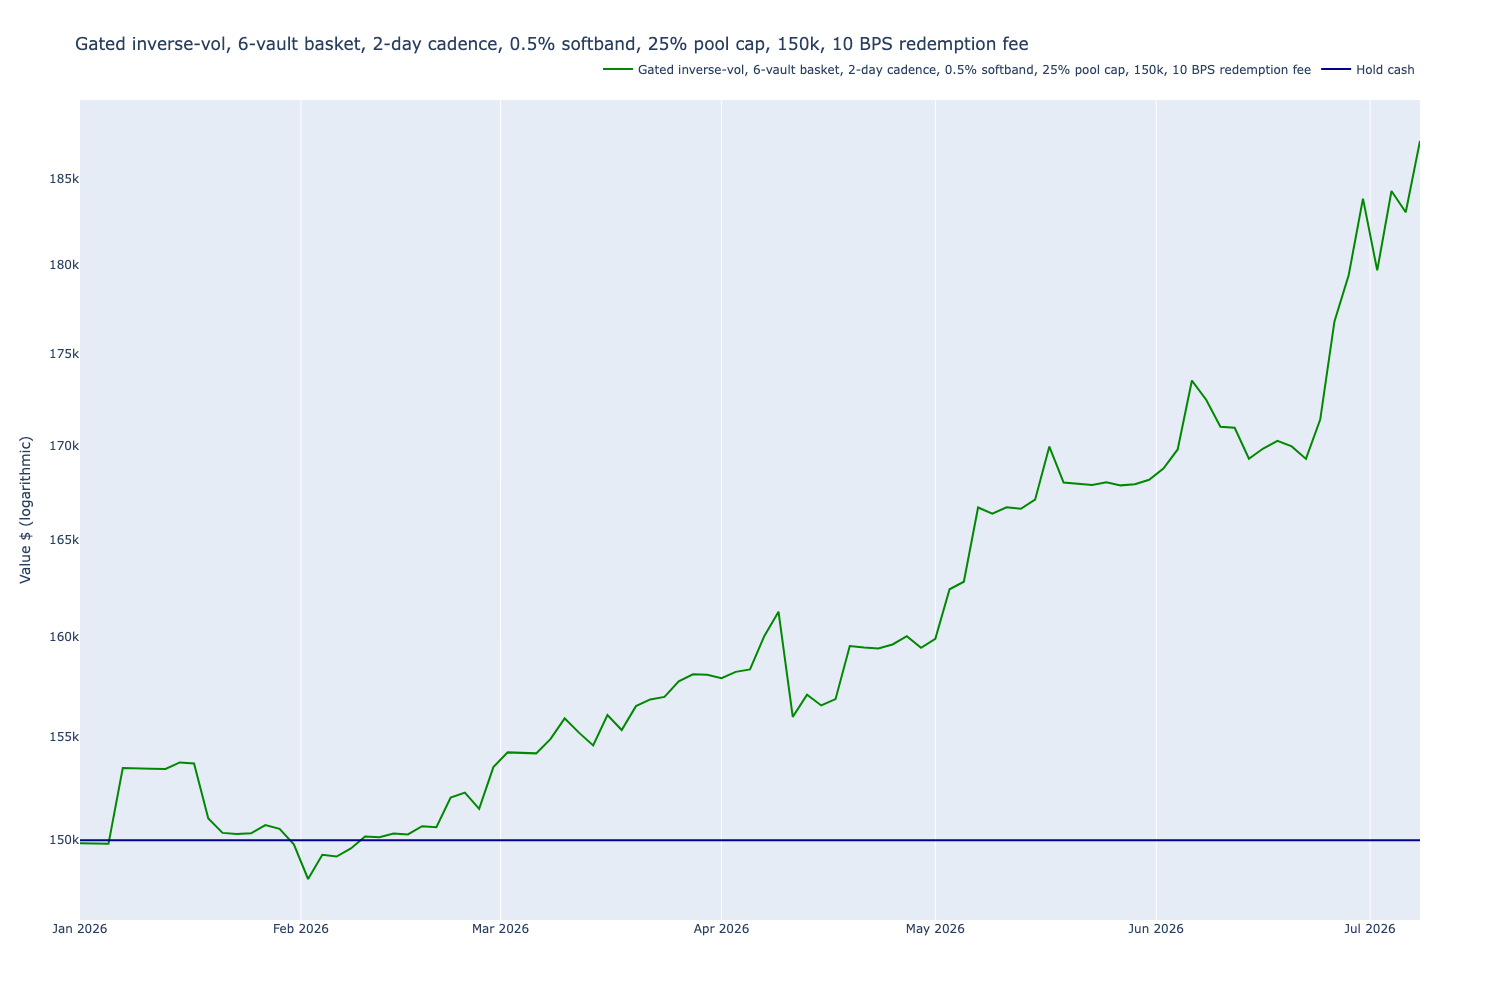

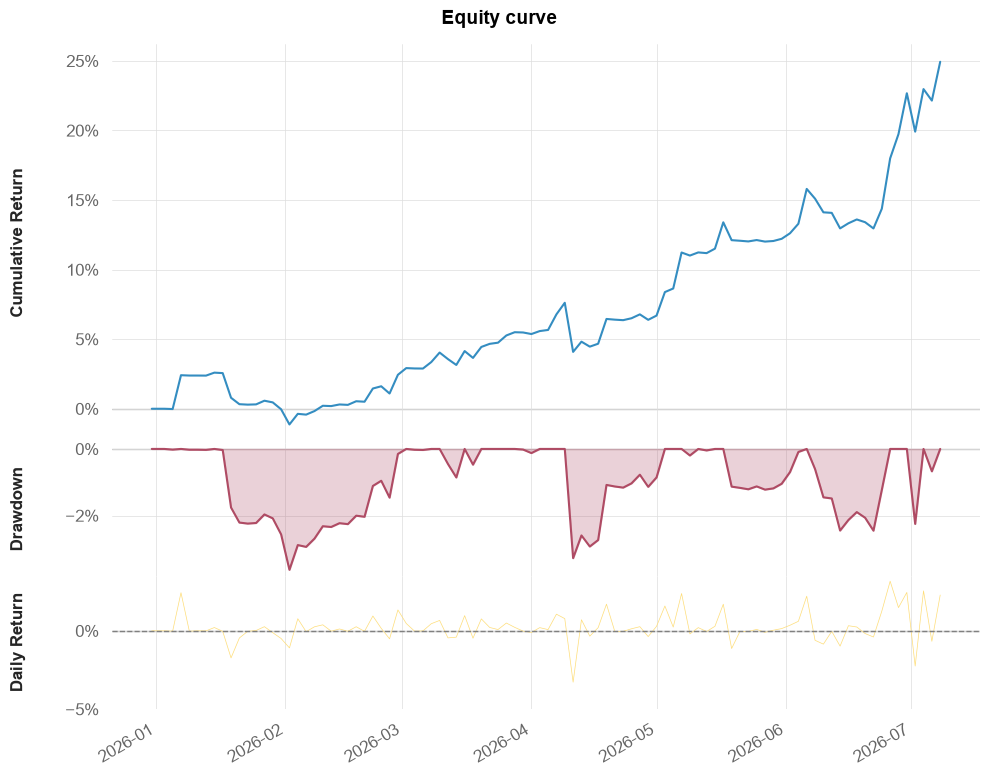

In [12]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)


# Asset weights

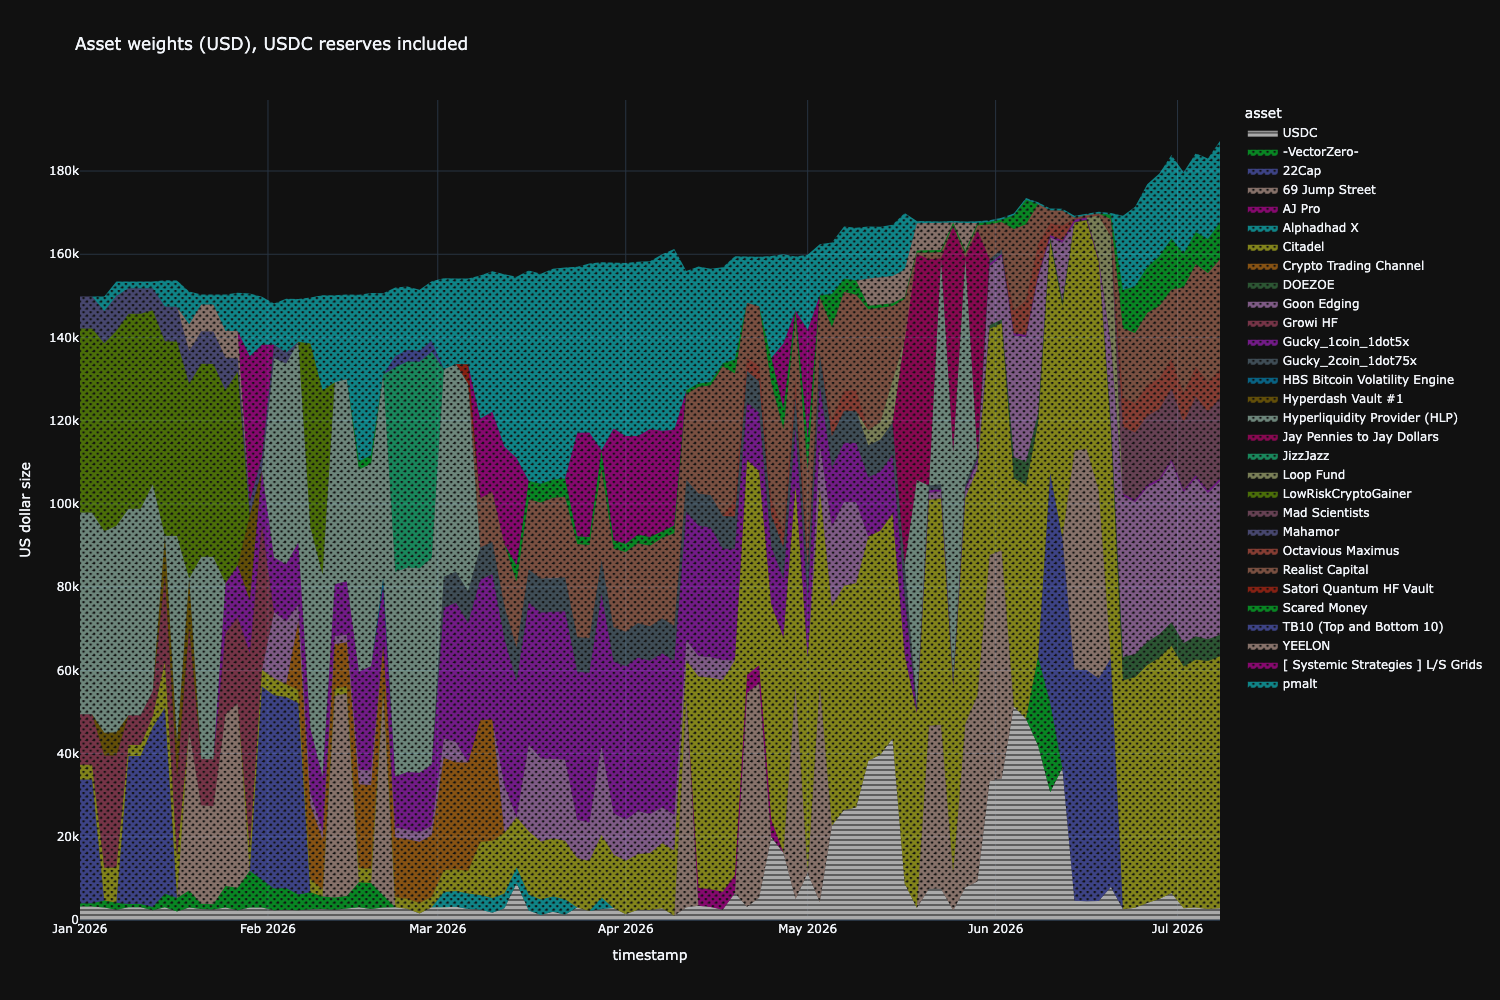

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2026-07-08,Citadel,"$60,545.68",
Min position (excluding USDC),2026-06-18,DOEZOE,$100.82,
Mean position (excluding USDC),,,"$18,469.15",
Max position (excluding USDC),2026-06-04,Citadel,46.35%,
Min position (excluding USDC),2026-06-18,DOEZOE,0.06%,
Mean position (excluding USDC),,,12.15%,
Max position (including USDC),2026-06-14,22Cap,32.77%,
Min position (including USDC),2026-06-18,DOEZOE,0.06%,
Mean position (including USDC),,,10.83%,


In [13]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

fig = chart_renderer.render(equity_curve_by_asset)
display(fig)

display_dataframe_with_html(chart_renderer.render(weight_allocation_statistics))


# Monthly returns

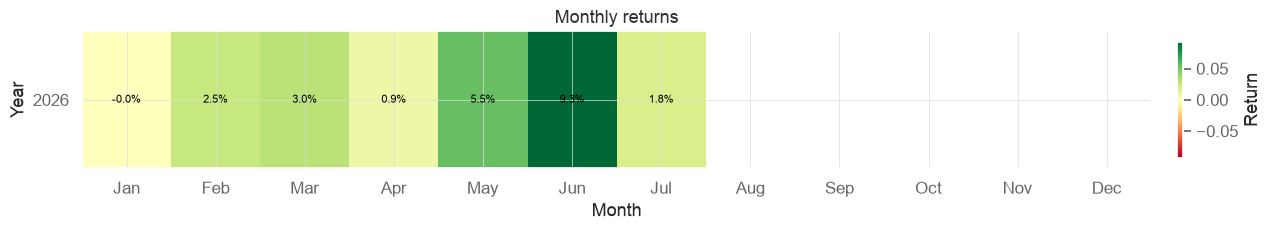

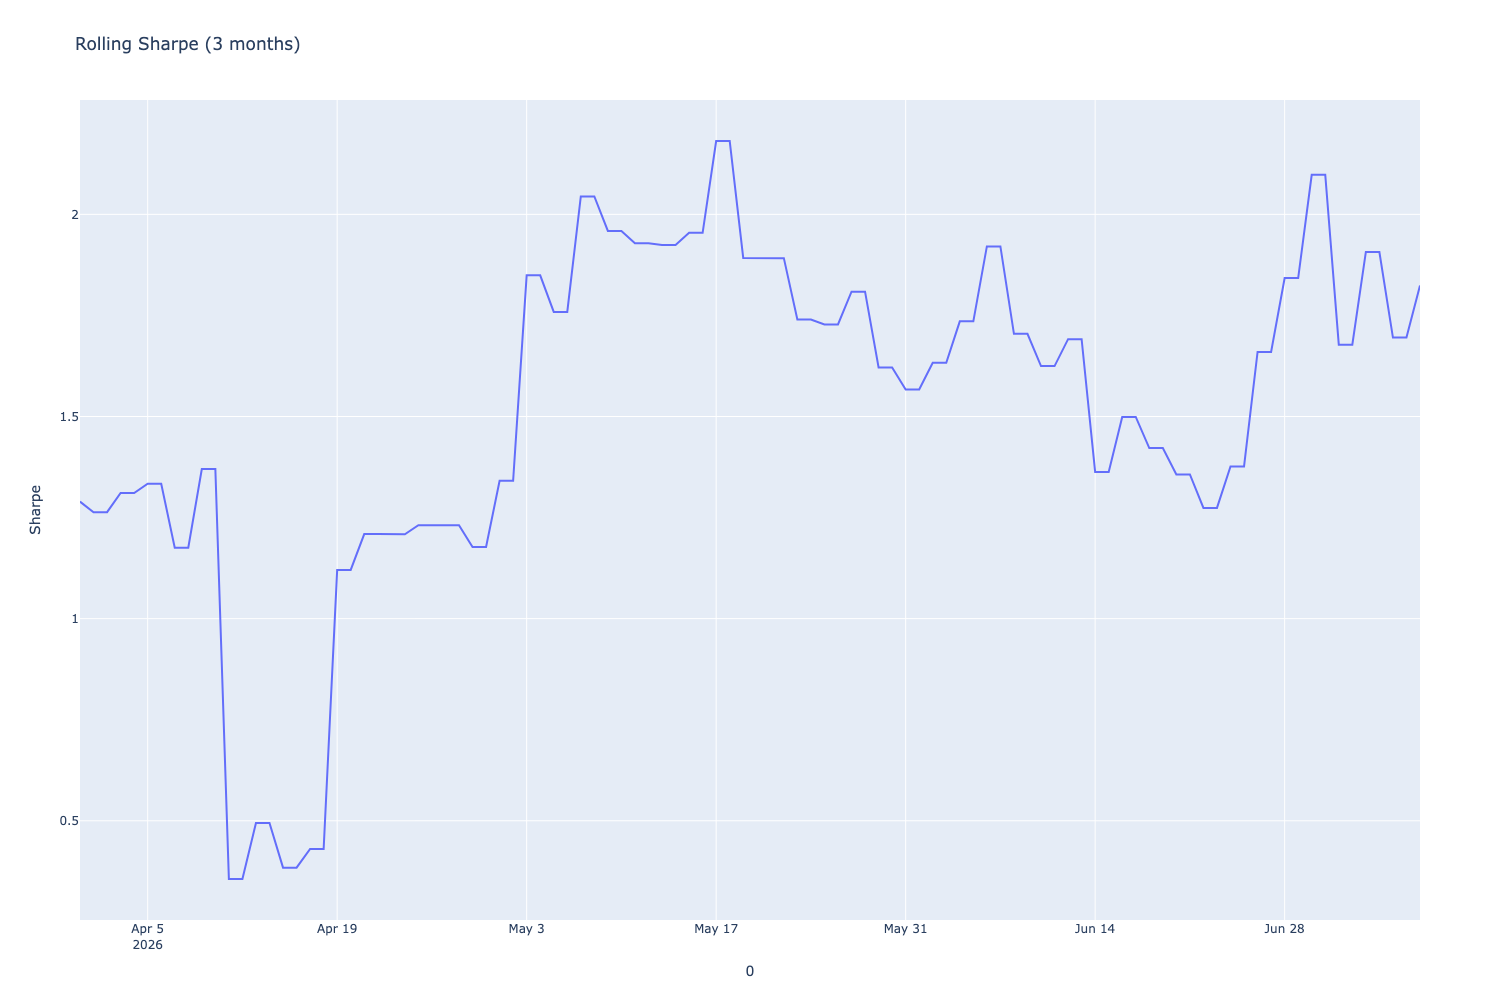

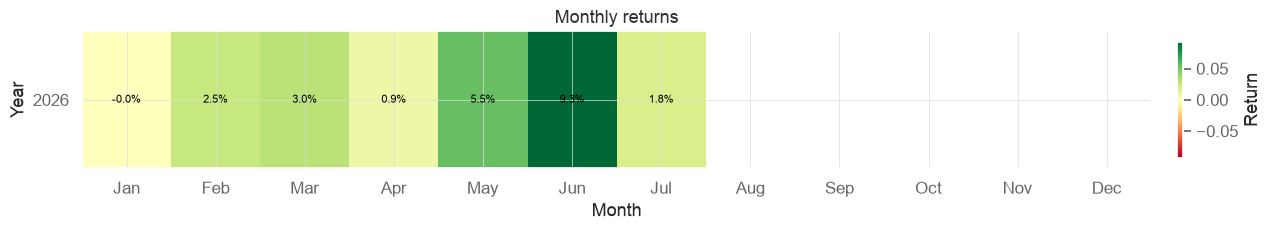

In [14]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time, calculate_rolling_sharpe
import plotly.express as px

display(visualise_returns_over_time(returns))

rolling_sharpe = calculate_rolling_sharpe(returns, freq="D", periods=90)
fig = px.line(rolling_sharpe, title="Rolling Sharpe (3 months)")
fig.update_layout(showlegend=False); fig.update_yaxes(title="Sharpe")
fig.show()


# Benchmark comparison and positions

In [15]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

display(compare_strategy_backtest_to_multiple_assets(state, strategy_universe, display=False, asset_count=2))

profit_by_position = sorted(
    ((p.get_realised_profit_usd() or 0.0, p) for p in positions),
    key=lambda x: x[0], reverse=True,
)
def pos_rows(items):
    return pd.DataFrame([{ 'Profit USD': pnl, 'Pair': p.pair.base.token_symbol,
        'Opened': p.opened_at, 'Closed': p.closed_at, 'Trades': len(p.trades) } for pnl, p in items])
print("Top 10 positions by profit:")
display(pos_rows(profit_by_position[:10]))
print("Biggest 8 losers:")
display(pos_rows(sorted(profit_by_position, key=lambda x: x[0])[:8]))

display(chart_renderer.render(positions_at_end))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0,0,0
Time in Market,0.49,0.98,0.98
Cumulative Return,0.25,-0.32,-0.45
CAGR﹪,0.54,-0.52,-0.68
Sharpe,3.34,-1.28,-1.43
Prob. Sharpe Ratio,0.99,0.18,0.15
Smart Sharpe,3.25,-1.24,-1.39
Sortino,6.24,-1.72,-1.93


Top 10 positions by profit:


,Profit USD,Pair,Opened,Closed,Trades
0,10250.178182,Realist Ca,2026-03-08,NaT,49
1,8137.694647,pmalt,2026-01-05,NaT,59
2,3580.215986,Scared Mon,2026-04-25,2026-06-08,11
3,1738.329877,Goon Edgin,2026-02-02,2026-02-20,7
4,1370.802619,69 Jump St,2026-05-21,2026-06-04,6
5,1265.283169,Scared Mon,2026-03-14,2026-04-21,10
6,1079.256798,Gucky_1coi,2026-01-25,NaT,25
7,1058.705099,JizzJazz,2026-02-22,2026-03-02,2
8,871.834515,Octavious,2026-05-05,2026-05-11,3
9,851.318105,[ Systemic,2026-03-08,2026-03-16,4


Biggest 8 losers:


,Profit USD,Pair,Opened,Closed,Trades
0,-1281.634634,Goon Edgin,2026-03-16,2026-04-19,13
1,-1268.628271,-VectorZer,2026-01-01,2026-02-22,18
2,-1209.698954,Goon Edgin,2026-06-12,2026-06-14,2
3,-1136.801075,Hyperdash,2026-01-29,2026-01-31,2
4,-957.374725,Mahamor,2026-01-01,2026-02-06,6
5,-922.231469,Citadel,2026-01-01,2026-01-19,6
6,-823.965673,Hyperdash,2026-01-15,2026-01-21,4
7,-652.110684,Goon Edgin,2026-02-22,2026-03-06,6


,token,value,vault,protocol,link
position_id,,,,,
9,pmalt,19532.845699,pmalt,hyperliquid,0x4dec0a851849056e259128464ef28ce78afa27f6
16,Gucky_1coi,565.004705,Gucky_1coin_1dot5x,hyperliquid,0xd2f03635901956b950737bbf02463dfad9f2e9e1
19,Citadel,60545.676419,Citadel,hyperliquid,0xda51323fe9800c8365646ad5c7ade0dd17fdc167
36,Realist Ca,26478.599334,Realist Capital,hyperliquid,0x77fee2df7bad4f1db93052fa82bf78eaab771a16
64,DOEZOE,5189.237620,DOEZOE,hyperliquid,0xcae0d1558b70b92ee9fd0acb20cb639c8c28ae69
65,Octavious,6867.793802,Octavious Maximus,hyperliquid,0x45c42fbd450b5506f8dc819d46036630fe75b81e
71,Goon Edgin,36938.476572,Goon Edging,hyperliquid,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f
72,Scared Mon,8899.935987,Scared Money,hyperliquid,0x5290ab34acb59cfe1371baa5782eba14433d308f
73,Mad Scient,19362.488118,Mad Scientists,hyperliquid,0x565b1c32936bdaa526947178acc95c5b08cfacc4


# Cash deployment diagnostics

Why does the strategy hold cash? Per cycle, the allocator redistributes equity a capped
position cannot take to the *remaining selected* signals, but it hard-stops at
`max_assets_in_portfolio` positions — so once all selected vaults hit their caps
(`per_position_cap_of_pool_pct` x vault TVL, or `max_concentration_pct` x investable equity),
the remainder is stranded as cash. This section quantifies which cap binds and how much
cash it strands, parsed from the per-cycle diagnostics messages.


,value
cycles,95.00
mean cash %,6.06
median cash %,2.00
max cash %,100.00
final-cycle cash %,1.42
mean deployment shortfall % of investable,0.10
cycles with shortfall > 10% of investable,0.00
mean signals pool-capped per cycle,2.23
mean signals concentration-capped per cycle,1.71
cycles where ALL selected signals were pool-capped,0.00


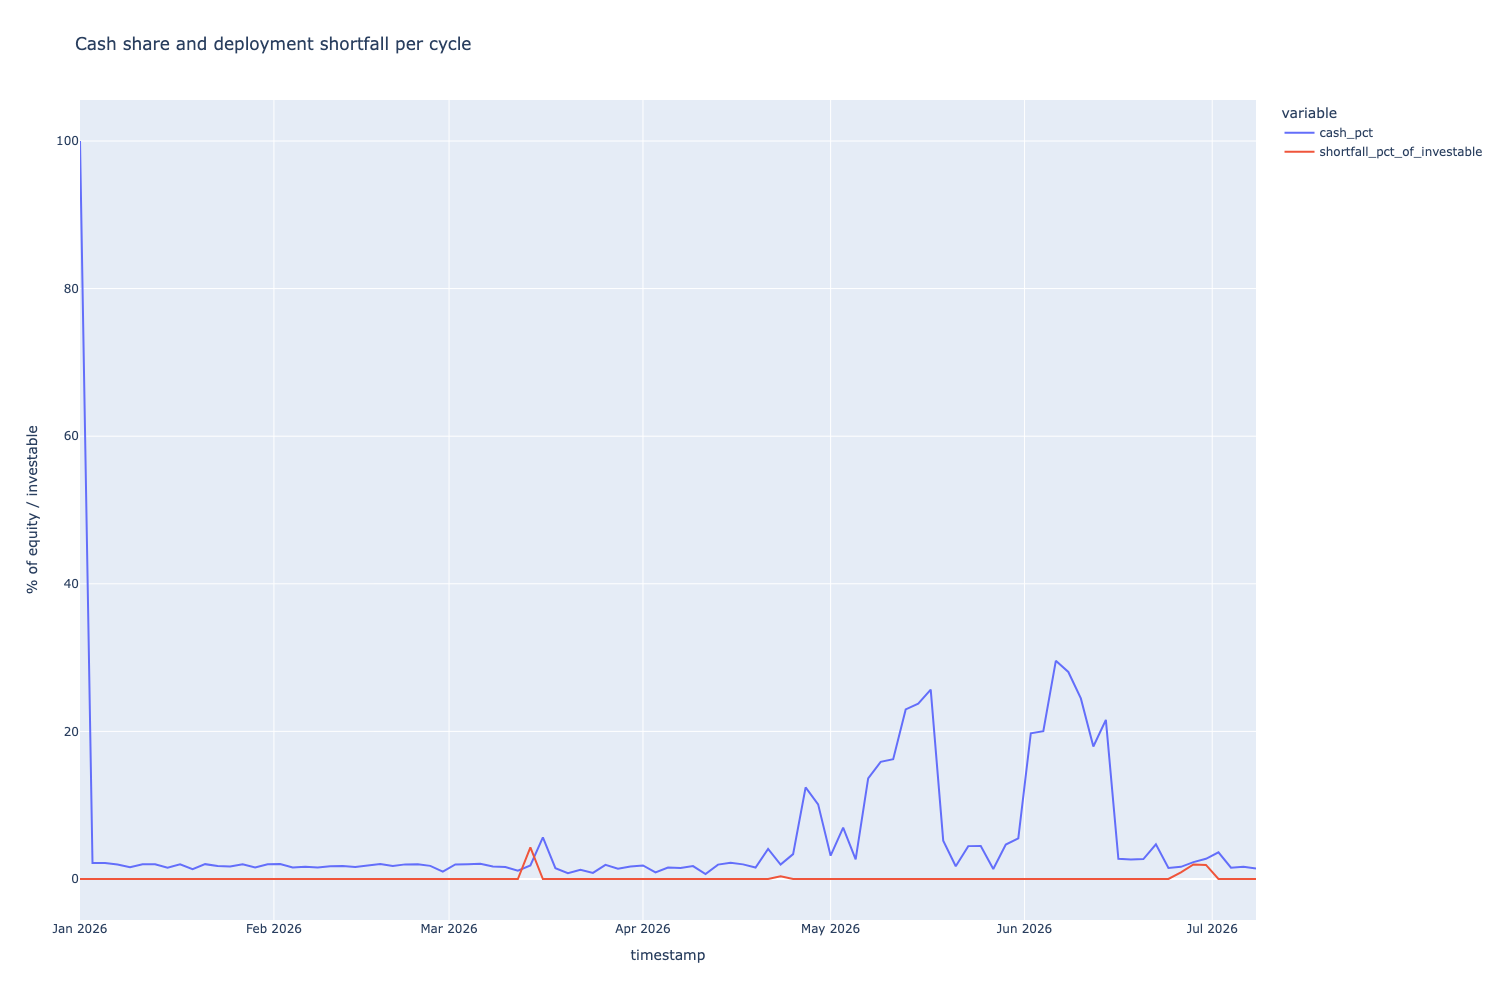

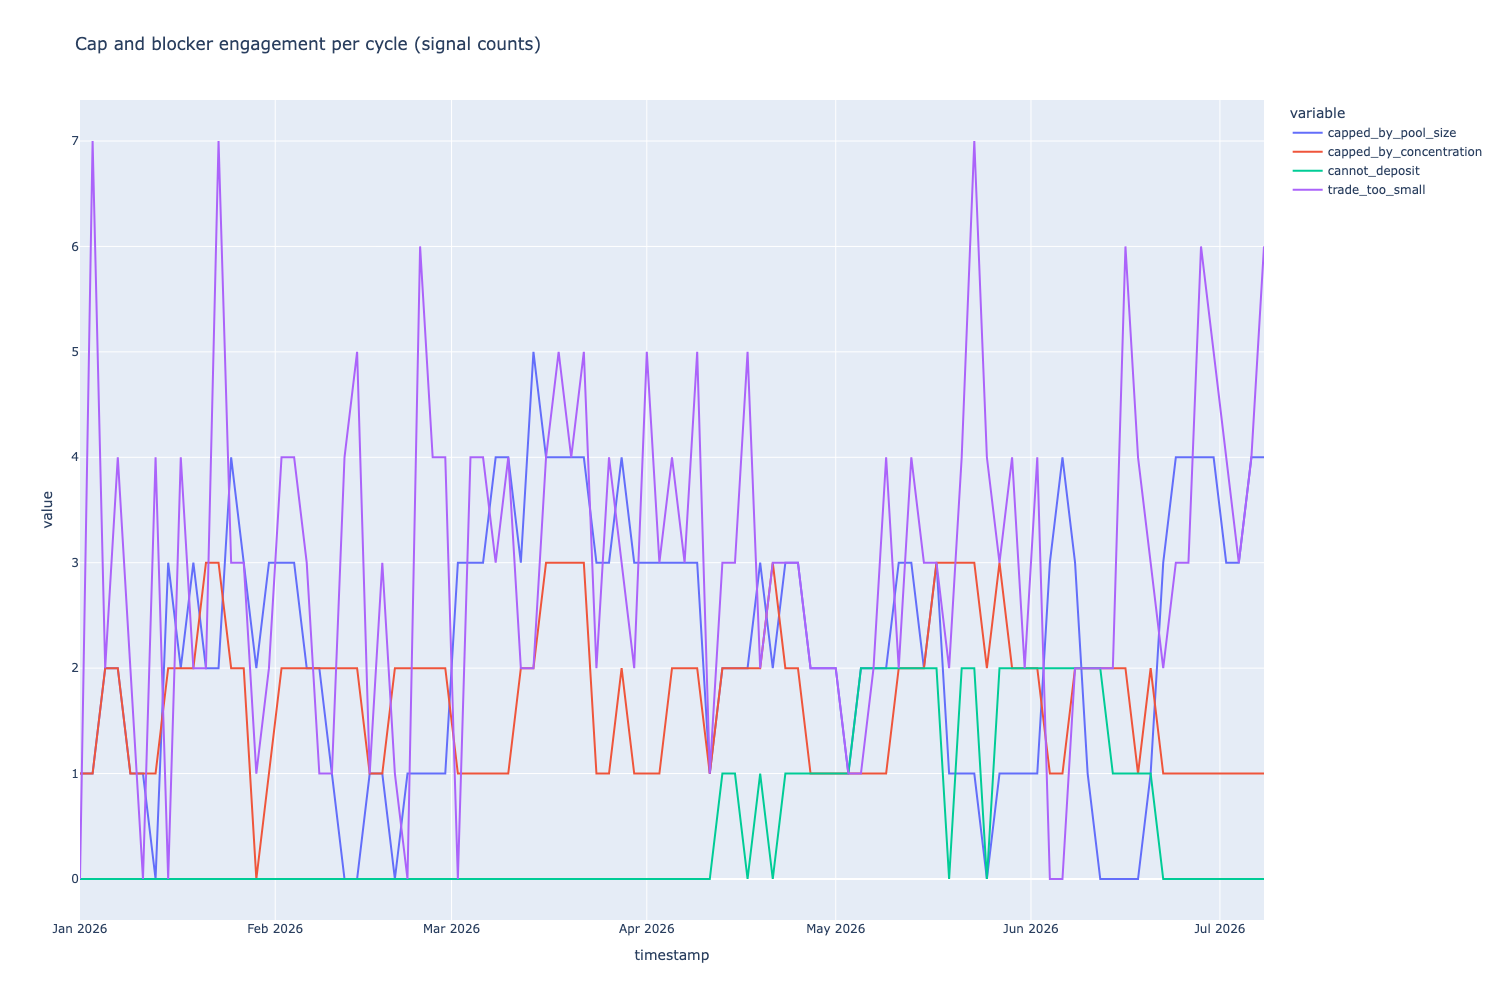

Last 30 cycles:


,cash_pct,cannot_deposit,deposit_window_skips,capped_by_pool_size,top_signal_pair
timestamp,,,,,
2026-05-11,16.2,2,0,3,YEELON-USDC
2026-05-13,23.0,2,0,3,YEELON-USDC
2026-05-15,23.8,2,0,2,YEELON-USDC
2026-05-17,25.7,2,0,3,YEELON-USDC
2026-05-19,5.2,0,0,1,YEELON-USDC
2026-05-21,1.7,2,0,1,YEELON-USDC
2026-05-23,4.5,2,0,1,YEELON-USDC
2026-05-25,4.5,0,0,0,Hyperliqui-USDC
2026-05-27,1.4,2,0,1,YEELON-USDC


In [16]:
import re

import plotly.express as px


def extract_allocation_df(state) -> pd.DataFrame:
    """Parse per-cycle equity/cash/allocation and cap-flag counts from diagnostics messages."""
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)

        def _usd(label):
            match = re.search(rf'{re.escape(label)}: ([0-9,.\-]+) USD', message)
            return float(match.group(1).replace(',', '')) if match else float('nan')

        def _count(label):
            match = re.search(rf'{re.escape(label)}: ([0-9]+)', message)
            return int(match.group(1)) if match else 0

        rows.append({
            'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.timezone.utc).replace(tzinfo=None),
            'total_equity': _usd('Total equity'),
            'cash': _usd('Cash'),
            'investable': _usd('Investable equity'),
            'accepted': _usd('Accepted investable equity'),
            'discarded_liquidity': _usd('Discarded allocation because of lack of lit liquidity'),
            'candidates': _count('Candidate signals created'),
            'selected': _count('Selected survivor signals'),
            'capped_by_pool_size': _count('Signals with flag capped_by_pool_size'),
            'capped_by_concentration': _count('Signals with flag capped_by_concentration'),
            'cannot_deposit': _count('Signals with flag cannot_deposit'),
            'deposit_window_skips': _count('Candidates skipped for closed deposit window'),
            'trade_too_small': _count('Signals with flag individual_trade_size_too_small'),
            'top_signal_pair': (re.search(r'Top signal pair: (\S+)', message).group(1)
                                if re.search(r'Top signal pair: (\S+)', message) else None),
        })
    return pd.DataFrame(rows).set_index('timestamp')


alloc_df = extract_allocation_df(state)
alloc_df['cash_pct'] = alloc_df['cash'] / alloc_df['total_equity'] * 100
alloc_df['deployment_shortfall'] = alloc_df['investable'] - alloc_df['accepted']
alloc_df['shortfall_pct_of_investable'] = alloc_df['deployment_shortfall'] / alloc_df['investable'] * 100

deployment_summary = pd.Series({
    'cycles': len(alloc_df),
    'mean cash %': alloc_df['cash_pct'].mean(),
    'median cash %': alloc_df['cash_pct'].median(),
    'max cash %': alloc_df['cash_pct'].max(),
    'final-cycle cash %': alloc_df['cash_pct'].iloc[-1],
    'mean deployment shortfall % of investable': alloc_df['shortfall_pct_of_investable'].mean(),
    'cycles with shortfall > 10% of investable': int((alloc_df['shortfall_pct_of_investable'] > 10).sum()),
    'mean signals pool-capped per cycle': alloc_df['capped_by_pool_size'].mean(),
    'mean signals concentration-capped per cycle': alloc_df['capped_by_concentration'].mean(),
    'cycles where ALL selected signals were pool-capped': int(
        ((alloc_df['capped_by_pool_size'] >= alloc_df['selected']) & (alloc_df['selected'] > 0)).sum()
    ),
    'cycles with < 5 gated candidates': int((alloc_df['candidates'] < int(Parameters.max_assets_in_portfolio)).sum()),
    'cycles with a cannot_deposit signal (closed deposit window)': int((alloc_df['cannot_deposit'] > 0).sum()),
    'cycles skipping closed-window candidates at selection': int((alloc_df['deposit_window_skips'] > 0).sum()),
    'total closed-window candidates skipped at selection': int(alloc_df['deposit_window_skips'].sum()),
    'mean cash % when cannot_deposit engaged': alloc_df.loc[alloc_df['cannot_deposit'] > 0, 'cash_pct'].mean(),
    'mean cash % when no cannot_deposit': alloc_df.loc[alloc_df['cannot_deposit'] == 0, 'cash_pct'].mean(),
}, name='value')
display(deployment_summary.to_frame().round(2))

fig = px.line(alloc_df[['cash_pct', 'shortfall_pct_of_investable']], title='Cash share and deployment shortfall per cycle')
fig.update_yaxes(title='% of equity / investable')
fig.show()

fig = px.line(alloc_df[['capped_by_pool_size', 'capped_by_concentration', 'cannot_deposit', 'trade_too_small']], title='Cap and blocker engagement per cycle (signal counts)')
fig.show()

print('Last 30 cycles:')
display(alloc_df[['cash_pct', 'cannot_deposit', 'deposit_window_skips', 'capped_by_pool_size', 'top_signal_pair']].tail(30).round(1))


In [17]:
# Shared analysis helpers used by every grid in this notebook.
#
# Kept in their own cell deliberately: earlier variants defined these inside a grid cell, and
# replacing that grid in the next variant silently removed them.
from tradeexecutor.analysis.weights import calculate_asset_weights, visualise_weights


def deployment_stats(state_) -> dict:
    """Cash, deployment shortfall and cap-binding counts for one run.

    `extract_allocation_df()` returns the raw per-cycle fields; `cash_pct` and the shortfall
    percentage are derived from them above rather than inside that function, so recompute here.
    """
    alloc = extract_allocation_df(state_)
    if not len(alloc):
        return {}
    cash_pct = alloc["cash"] / alloc["total_equity"] * 100
    shortfall_pct = (alloc["investable"] - alloc["accepted"]) / alloc["investable"] * 100
    return {
        "Mean cash %": float(cash_pct.mean()),
        "Deployment shortfall %": float(shortfall_pct.mean()),
        "Cycles >10% unplaced": int((shortfall_pct > 10).sum()),
        "Pool-capped per cycle": float(alloc["capped_by_pool_size"].mean()),
        "Concentration-capped per cycle": float(alloc["capped_by_concentration"].mean()),
    }


def weight_concentration_stats(weights_series: pd.Series) -> dict:
    """Largest weight and effective position count from an asset weight timeline.

    `calculate_asset_weights()` returns a (timestamp, asset) MultiIndex of USD values, so normalise
    within each timestamp before measuring concentration. Reserves are dropped: cash is not a
    position and would flatter the diversification measure exactly when the strategy fails to
    deploy.
    """
    frame = weights_series.unstack(level=1).fillna(0.0)
    for reserve in ("USDC", "USDT", "USDC.e", "USDT0"):
        if reserve in frame.columns:
            frame = frame.drop(columns=[reserve])
    totals = frame.sum(axis=1)
    frame = frame.loc[totals > 0]
    if not len(frame):
        return {}
    normalised = frame.div(frame.sum(axis=1), axis=0)
    herfindahl = (normalised ** 2).sum(axis=1)
    return {
        "Mean largest weight": float(normalised.max(axis=1).mean()),
        "Max largest weight": float(normalised.max(axis=1).max()),
        "Effective positions": float((1.0 / herfindahl).mean()),
        "Mean held": float((normalised > 0.005).sum(axis=1).mean()),
    }


## End-of-backtest drill-down

The held vaults at the end, their TVL, and the pool cap each one imposes. If the sum of
pool caps is below investable equity, the cash pile is structural: the five selected
vaults simply cannot absorb the bankroll at a 15% TVL share.


In [18]:
#: Label derives from the configured cap - it was hardcoded to "15%" in the ancestor
#: notebooks, which silently mislabels any variant that changes the pool cap.
POOL_CAP_LABEL = f"Pool cap ({Parameters.per_position_cap_of_pool_pct:.0%} of TVL) USD"

final_rows = []
for position in state.portfolio.open_positions.values():
    pair = position.pair
    try:
        tvl_series = indicator_data.get_indicator_series('tvl', pair=pair)
        last_tvl = float(tvl_series.dropna().iloc[-1])
    except Exception:
        last_tvl = float('nan')
    final_rows.append({
        'Vault': pair.base.token_symbol,
        'Position value USD': float(position.get_value()),
        'Vault TVL USD': last_tvl,
        POOL_CAP_LABEL: last_tvl * float(Parameters.per_position_cap_of_pool_pct),
    })
final_positions_df = pd.DataFrame(final_rows).sort_values('Position value USD', ascending=False)
display(final_positions_df.round(0))

final_cycle = alloc_df.iloc[-1]
print(f"Final cycle equity: {final_cycle['total_equity']:,.0f} USD, cash: {final_cycle['cash']:,.0f} USD ({final_cycle['cash_pct']:.1f}%)")
print(f"Investable (98% target): {final_cycle['investable']:,.0f} USD, accepted by caps: {final_cycle['accepted']:,.0f} USD")
print(f"Sum of pool caps across held vaults: {final_positions_df[POOL_CAP_LABEL].sum():,.0f} USD")

print()
print('Last cycle raw diagnostics:')
last_ts = max(state.visualisation.messages)
print('\n'.join(state.visualisation.messages[last_ts]))


,Vault,Position value USD,Vault TVL USD,Pool cap (33% of TVL) USD
2,Citadel,60546.0,558891.0,184434.0
6,Goon Edgin,36938.0,108169.0,35696.0
3,Realist Ca,26479.0,485292.0,160146.0
0,pmalt,19533.0,513987.0,169616.0
8,Mad Scient,19362.0,59388.0,19598.0
7,Scared Mon,8900.0,50278.0,16592.0
5,Octavious,6868.0,20166.0,6655.0
4,DOEZOE,5189.0,15752.0,5198.0
1,Gucky_1coi,565.0,100475.0,33157.0


Final cycle equity: 187,219 USD, cash: 2,663 USD (1.4%)
Investable (98% target): 183,475 USD, accepted by caps: 183,475 USD
Sum of pool caps across held vaults: 631,091 USD

Last cycle raw diagnostics:
Cycle: #95
Rebalanced: 👍
Open/about to open positions: 9
Max position value change: 2,633.41 USD
Rebalance threshold: 75.00 USD
Trades decided: 3
Pairs meeting inclusion criteria: 195
Pairs meeting TVL inclusion criteria: 198
Candidate signals created: 191
Selected survivor signals: 9
Candidates skipped for closed deposit window: 0
CAGR lookback days: 360
Sharpe lookback days: 120
CAGR weight (blend): 0.7
Total equity: 187,219.01 USD
Cash: 2,663.00 USD
Redeemable capital: 184,556.01 USD
Pending redemptions: 0.00 USD
Investable equity: 183,474.63 USD
Accepted investable equity: 183,474.63 USD
Allocated to signals: 183,474.63 USD
Discarded allocation because of lack of lit liquidity: 39,186.95 USD
Rebalance volume: 0.00 USD
Top signal pair: Citadel-USDC
Top signal value: 397890.4407572532


# Redemption fee verification and cost accounting

Verify the fee actually reached the executed sell prices, and total up what it cost.

Two sell paths exist and both must be checked:

- **Full closes** go through `PositionManager.close_position()`, which prices straight off
  `BacktestPricing.get_sell_price()`, so the fee lands as `share price x (1 - fee)`.
- **Partial reductions** of a Hypercore position go through `PositionManager.adjust_position()`,
  which overrides the pricing-model price with the position's *marked* price
  (trade-executor `7e673dc6`, so live partial redemptions size off the live implied share price).
  That marked price is itself produced by `BacktestValuationModel` from `get_sell_price()` at the
  same cycle timestamp, so the fee is still charged — but the trade's `planned_mid_price` is
  overwritten with the same value and can no longer be used to measure it.

The verification below is therefore independent of both paths: it compares each executed sell
price against the vault's own daily close (share price) at the time the trade was planned.


,Trades,Configured fee,Median implied fee,Mean implied fee,Within 1 BPS of configured
Sell type,,,,,
Full close,64,0.100%,0.100%,-0.029%,70.3%
Partial reduction,145,0.100%,0.100%,0.175%,57.2%
All sells,209,0.100%,0.100%,0.112%,61.2%


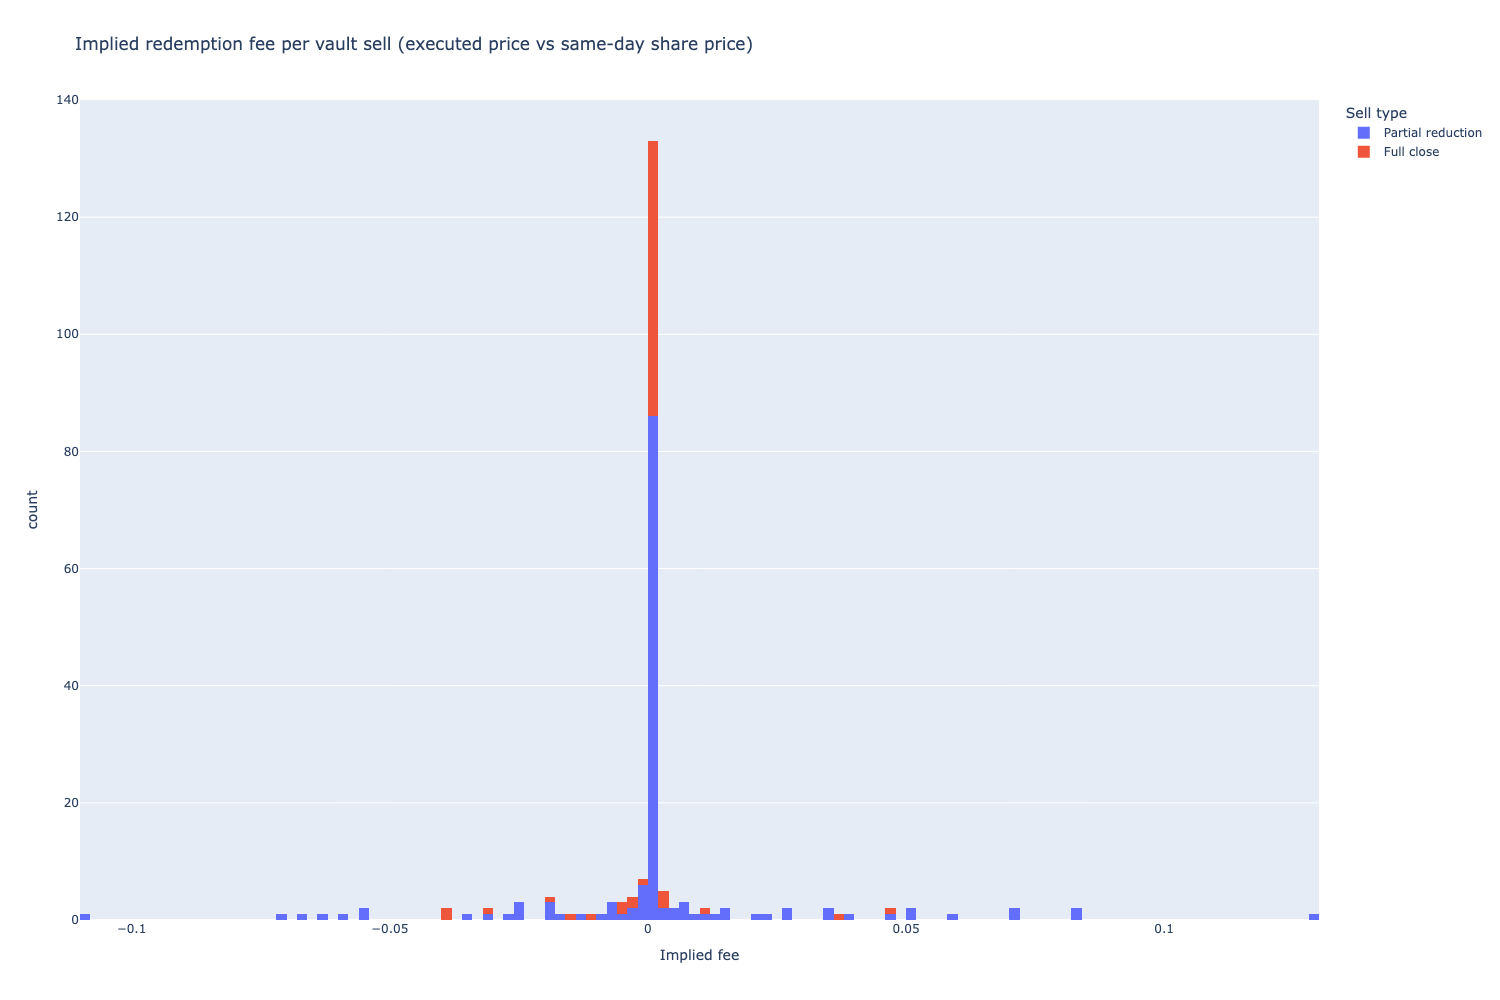

,Vault sell trades,Redemption volume USD,Redemption fee paid USD,Fee as % of initial capital,Fee as % of final equity,Redemption turnover x initial capital
0,209,"$2,338,191","$2,341",1.56%,1.25%,15.6x


,Sells,Proceeds USD,Fee paid USD
Vault,,,
69 Jump St,12,"$502,037",$502.54
Hyperliqui,6,"$306,606",$306.91
22Cap,5,"$177,864",$178.04
Jay Pennie,3,"$162,578",$162.74
[ Systemic,11,"$157,958",$158.12
Goon Edgin,24,"$143,780",$143.92
pmalt,28,"$132,766",$132.90
Realist Ca,22,"$119,583",$119.70
LowRiskCry,3,"$95,648",$95.74


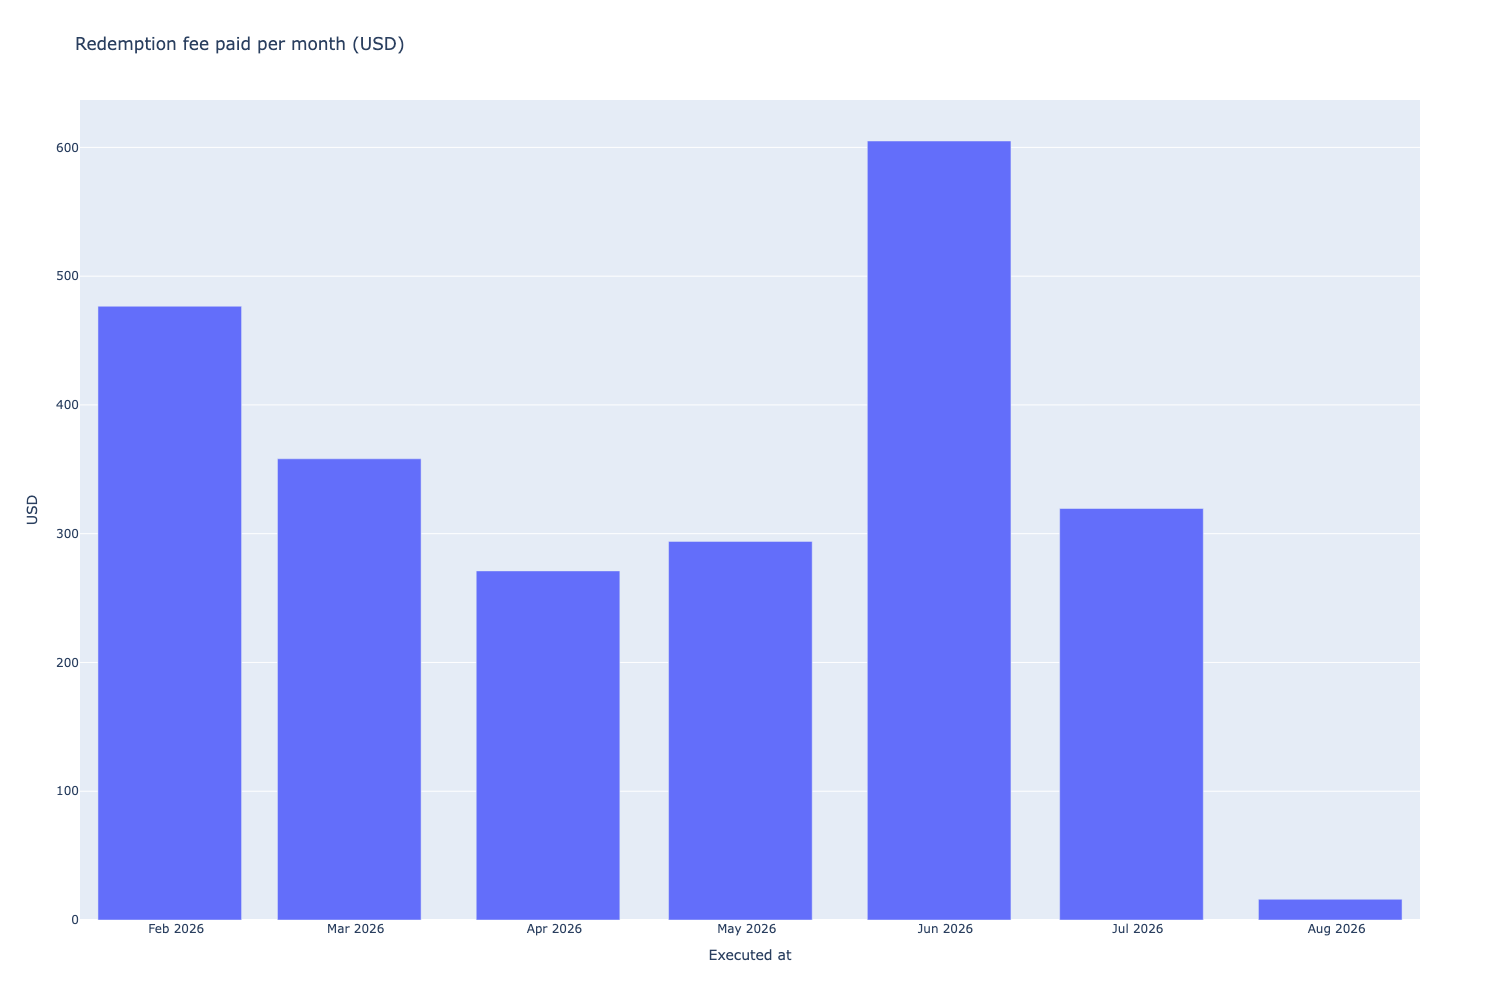

In [19]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        closes = candles.set_index('timestamp')['close'].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float('nan')


def build_vault_sell_df(state_, fee_: float) -> pd.DataFrame:
    """Every successful vault sell, with the fee implied by its executed price.

    :param fee_:
        Redemption fee configured for the run that produced ``state_``.
    """
    rows = []
    for trade in state_.portfolio.get_all_trades():
        if not trade.pair.is_vault():
            continue
        if not trade.is_sell() or not trade.is_success():
            continue
        share_price = get_vault_share_price(trade.pair, trade.opened_at)
        proceeds = abs(float(trade.executed_reserve or 0.0))
        rows.append({
            'Vault': trade.pair.base.token_symbol,
            'Planned at': trade.opened_at,
            'Executed at': trade.executed_at,
            'Sell type': 'Full close' if trade.closing else 'Partial reduction',
            'Share price': share_price,
            'Planned price': float(trade.planned_price),
            'Implied fee': float(1.0 - trade.planned_price / share_price) if share_price == share_price else float('nan'),
            'Proceeds USD': proceeds,
            'Fee paid USD': proceeds * fee_ / (1.0 - fee_) if fee_ else 0.0,
        })
    return pd.DataFrame(rows)


def summarise_implied_fees(df: pd.DataFrame, fee_: float) -> pd.DataFrame:
    """Implied-fee statistics, split by sell type."""
    rows = []
    for sell_type, group in list(df.groupby('Sell type')) + [('All sells', df)]:
        implied = group['Implied fee'].dropna()
        rows.append({
            'Sell type': sell_type,
            'Trades': len(group),
            'Configured fee': fee_,
            'Median implied fee': float(implied.median()),
            'Mean implied fee': float(implied.mean()),
            'Within 1 BPS of configured': float((implied.sub(fee_).abs() <= 0.0001).mean()),
        })
    return pd.DataFrame(rows).set_index('Sell type')


fee = Parameters.vault_redemption_fee
vault_sell_df = build_vault_sell_df(state, fee)

display(
    summarise_implied_fees(vault_sell_df, fee).style.format({
        'Configured fee': '{:.3%}',
        'Median implied fee': '{:.3%}',
        'Mean implied fee': '{:.3%}',
        'Within 1 BPS of configured': '{:.1%}',
    }).set_caption('Implied redemption fee by sell type')
)

fig = px.histogram(
    vault_sell_df,
    x='Implied fee',
    color='Sell type',
    nbins=120,
    title='Implied redemption fee per vault sell (executed price vs same-day share price)',
)
fig.show()

total_fee_usd = float(vault_sell_df['Fee paid USD'].sum())
total_proceeds_usd = float(vault_sell_df['Proceeds USD'].sum())
final_equity = float(equity.iloc[-1])

fee_summary_df = pd.DataFrame([{
    'Vault sell trades': len(vault_sell_df),
    'Redemption volume USD': total_proceeds_usd,
    'Redemption fee paid USD': total_fee_usd,
    'Fee as % of initial capital': total_fee_usd / Parameters.initial_cash,
    'Fee as % of final equity': total_fee_usd / final_equity,
    'Redemption turnover x initial capital': total_proceeds_usd / Parameters.initial_cash,
}])
display(fee_summary_df.style.format({
    'Redemption volume USD': '${:,.0f}',
    'Redemption fee paid USD': '${:,.0f}',
    'Fee as % of initial capital': '{:.2%}',
    'Fee as % of final equity': '{:.2%}',
    'Redemption turnover x initial capital': '{:.1f}x',
}))

fee_by_vault_df = vault_sell_df.groupby('Vault').agg(
    **{
        'Sells': ('Proceeds USD', 'size'),
        'Proceeds USD': ('Proceeds USD', 'sum'),
        'Fee paid USD': ('Fee paid USD', 'sum'),
    }
).sort_values('Fee paid USD', ascending=False)
display(
    fee_by_vault_df.head(15).style.format({
        'Proceeds USD': '${:,.0f}',
        'Fee paid USD': '${:,.2f}',
    }).set_caption('Redemption fee paid by vault (top 15)')
)

monthly_fee = vault_sell_df.set_index('Executed at')['Fee paid USD'].resample('1ME').sum()
fig = px.bar(monthly_fee, title='Redemption fee paid per month (USD)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='USD')
fig.show()


# A/B against the same run without the redemption fee

The honest way to price the fee is to re-run the identical strategy on the identical universe
with the fee switched off, rather than to compare against NB53's committed numbers (vault data
is refreshed between runs, so those numbers drift for reasons unrelated to the fee).

The only difference between the two runs below is the vault sell-side fee.


In [20]:
# Same universe, same indicators, same decide_trades - only the redemption fee differs.
apply_vault_redemption_fee(strategy_universe, 0.0)

baseline_result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, 0.5% softband, 25% pool cap, 150k, no redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

# Restore the configured fee so the rest of the notebook sees the fee-charging universe.
apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

baseline_state = baseline_result.state
baseline_equity = calculate_equity_curve(baseline_state)
baseline_returns = calculate_returns(baseline_equity)
baseline_positions = [p for p in baseline_state.portfolio.get_all_positions() if not p.is_credit_supply()]
print(f"Baseline (no fee) final equity: ${baseline_equity.iloc[-1]:,.0f}")
print(f"10 BPS fee       final equity: ${equity.iloc[-1]:,.0f}")


Baseline (no fee) final equity: $190,327
10 BPS fee       final equity: $187,217


,Final equity,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown,Positions,Trades
"Baseline, no redemption fee","$190,327",26.88%,58.77%,3.59,6.81,-3.37%,73,499
10 BPS redemption fee,"$187,217",24.81%,54.06%,3.34,6.24,-3.63%,73,501
Difference,"$-3,110",-2.07%,-4.71%,-0.25,-0.57,-0.26%,0,2


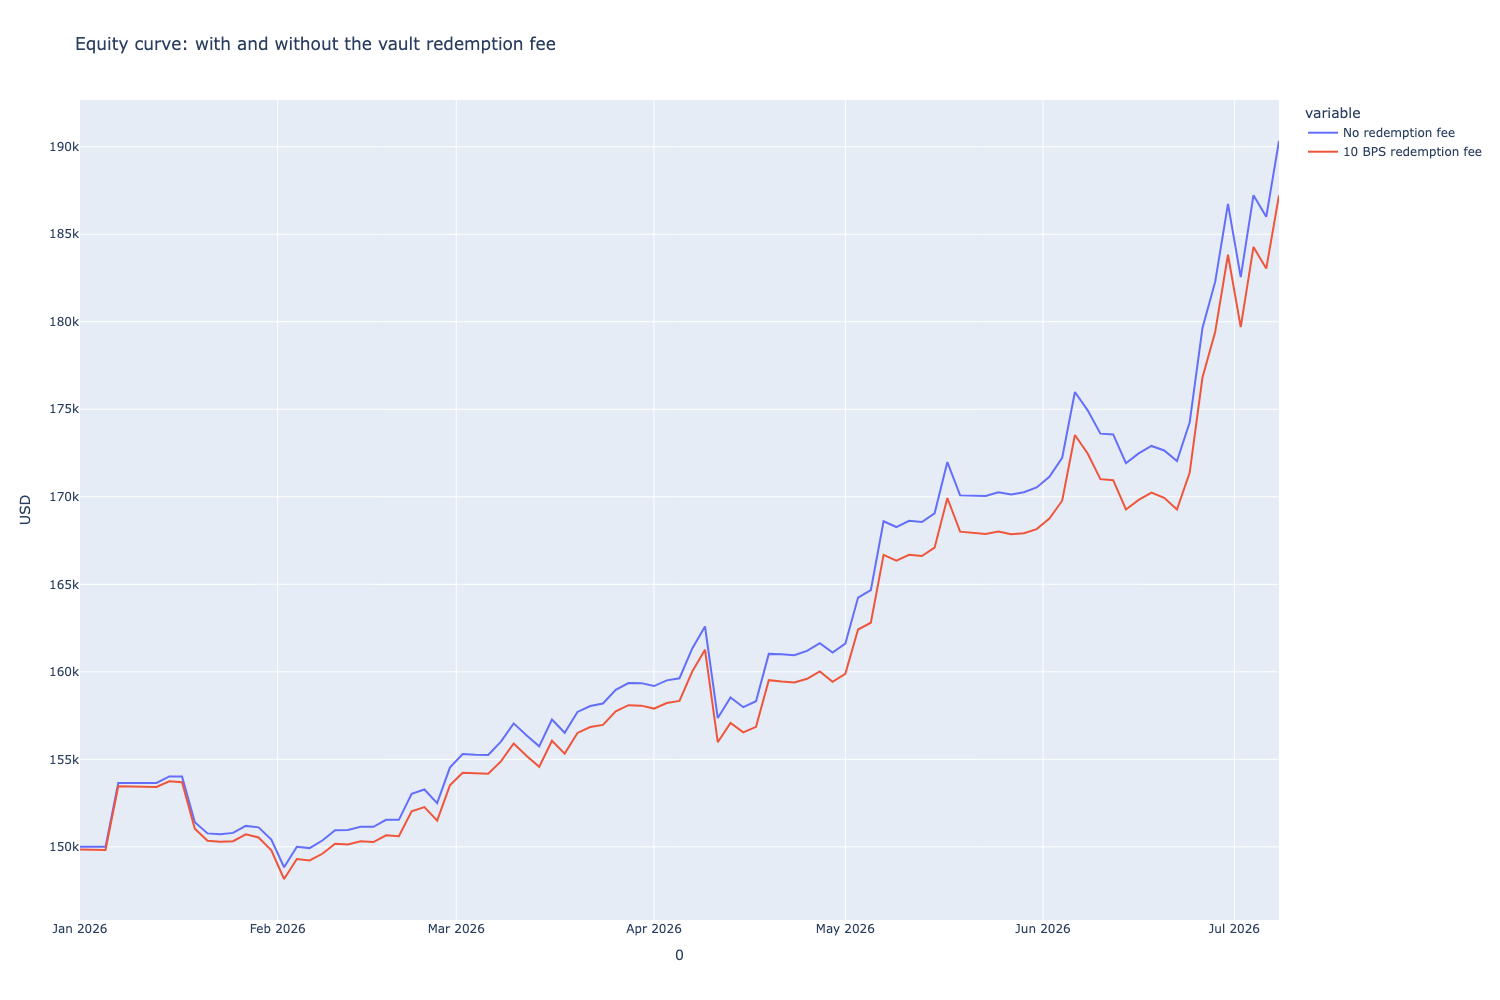

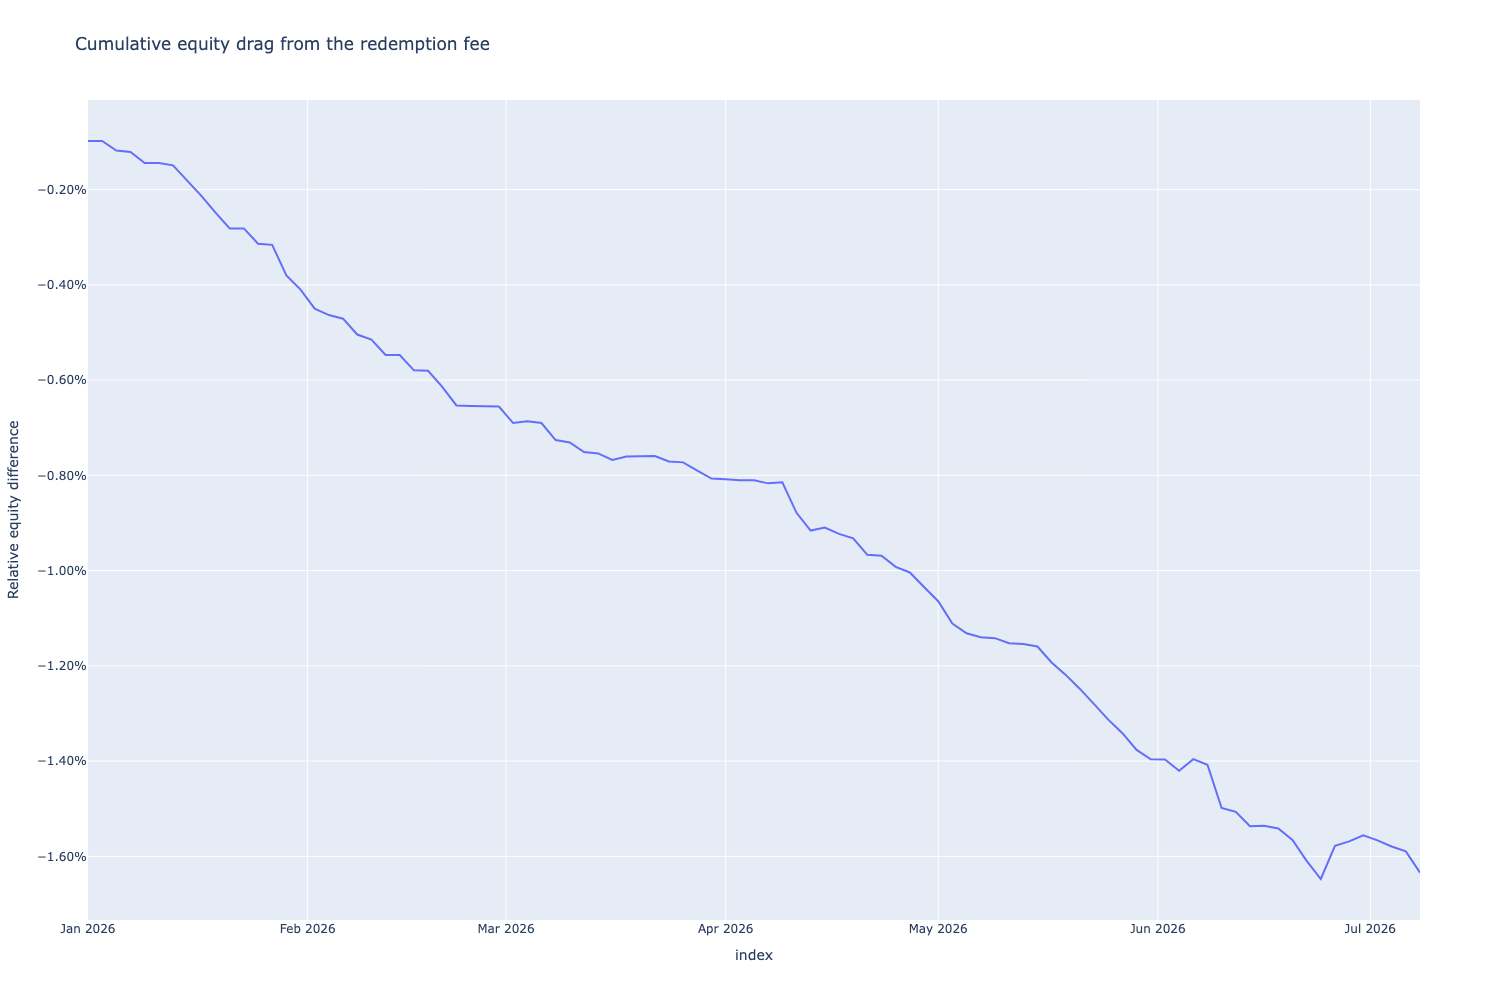

,Final equity difference USD,Final relative drag,Worst relative drag,Drag per year,Redemption fee paid USD (accounting)
0,"$-3,110",-1.63%,-1.65%,-3.17%,"$2,341"


In [21]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)


def summarise_run(label: str, equity_curve: pd.Series, state_) -> dict:
    """Headline metrics for one backtest run.

    The equity curve is sampled **once per strategy cycle**, so a 2-day cadence produces one
    observation every 48 hours. Annualising that series with ``periods=365`` would overstate its
    Sharpe and Sortino by ``sqrt(2)`` against a daily-cadence run and make the two incomparable.
    Resample onto a common daily grid first - a 2-day step becomes one non-zero day and one zero
    day, which annualises correctly and matches the basis used in the robustness cell.

    Max drawdown is still measured on whatever grid the strategy values itself: a 2-day cadence
    cannot observe a trough that opens and closes inside one of its cycles, so its drawdown is
    measured over fewer marks than a daily cadence. That is a property of the schedule, not of
    this function.
    """
    return_series = calculate_returns(equity_curve).resample("1D").sum(min_count=1).fillna(0.0).dropna()
    trades = list(state_.portfolio.get_all_trades())
    run_positions = [p for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()]
    return {
        'Run': label,
        'Final equity': float(equity_curve.iloc[-1]),
        'Cumulative return': float(equity_curve.iloc[-1] / Parameters.initial_cash - 1.0),
        'CAGR': float(calculate_cagr(return_series)),
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': float(calculate_max_drawdown(return_series)),
        'Positions': len(run_positions),
        'Trades': len(trades),
    }


comparison_df = pd.DataFrame([
    summarise_run('Baseline, no redemption fee', baseline_equity, baseline_state),
    summarise_run(f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee', equity, state),
]).set_index('Run')
delta = comparison_df.iloc[1] - comparison_df.iloc[0]
delta.name = 'Difference'
comparison_df = pd.concat([comparison_df, delta.to_frame().T])
display(comparison_df.style.format({
    'Final equity': '${:,.0f}',
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
    'Positions': '{:.0f}',
    'Trades': '{:.0f}',
}))

equity_comparison_df = pd.DataFrame({
    'No redemption fee': baseline_equity,
    f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee': equity,
}).ffill()
fig = px.line(equity_comparison_df, title='Equity curve: with and without the vault redemption fee')
fig.update_yaxes(title='USD')
fig.show()

drag = (equity_comparison_df.iloc[:, 1] / equity_comparison_df.iloc[:, 0] - 1.0)
fig = px.line(drag, title='Cumulative equity drag from the redemption fee')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='Relative equity difference', tickformat='.2%')
fig.show()

drag_df = pd.DataFrame([{
    'Final equity difference USD': float(equity.iloc[-1] - baseline_equity.iloc[-1]),
    'Final relative drag': float(drag.iloc[-1]),
    'Worst relative drag': float(drag.min()),
    'Drag per year': float(drag.iloc[-1]) / ((equity.index[-1] - equity.index[0]).days / 365.0),
    'Redemption fee paid USD (accounting)': total_fee_usd,
}])
display(drag_df.style.format({
    'Final equity difference USD': '${:,.0f}',
    'Final relative drag': '{:.2%}',
    'Worst relative drag': '{:.2%}',
    'Drag per year': '{:.2%}',
    'Redemption fee paid USD (accounting)': '${:,.0f}',
}))


In [22]:
# Control: the same implied-fee measurement on the no-fee baseline run.
#
# Hypercore partial reductions execute at the position's marked price, which is a cycle-start
# valuation and can differ from the same-day close for reasons that have nothing to do with the
# fee (stale marks, positions opened the same cycle, async settlement). The baseline run isolates
# that measurement noise: its implied fees must centre on zero, and the fee run must be the same
# distribution shifted by exactly the configured fee.
baseline_sell_df = build_vault_sell_df(baseline_state, 0.0)

control_df = pd.concat([
    summarise_implied_fees(baseline_sell_df, 0.0).assign(Run='Baseline, no fee'),
    summarise_implied_fees(vault_sell_df, Parameters.vault_redemption_fee).assign(Run='10 BPS fee'),
]).set_index('Run', append=True).reorder_levels(['Run', 'Sell type'])
display(control_df.style.format({
    'Configured fee': '{:.3%}',
    'Median implied fee': '{:.3%}',
    'Mean implied fee': '{:.3%}',
    'Within 1 BPS of configured': '{:.1%}',
}).set_caption('Implied fee measurement, fee run vs no-fee control'))

shift_df = pd.DataFrame([{
    'Median implied fee, baseline': float(baseline_sell_df['Implied fee'].median()),
    'Median implied fee, fee run': float(vault_sell_df['Implied fee'].median()),
    'Median shift': float(vault_sell_df['Implied fee'].median() - baseline_sell_df['Implied fee'].median()),
    'Mean shift': float(vault_sell_df['Implied fee'].mean() - baseline_sell_df['Implied fee'].mean()),
    'Configured fee': Parameters.vault_redemption_fee,
}])
display(shift_df.style.format('{:.3%}'))


,"Median implied fee, baseline","Median implied fee, fee run",Median shift,Mean shift,Configured fee
0,0.000%,0.100%,0.100%,0.096%,0.100%


# Vault price data coverage

Every metric above assumes the daily candle series carries a daily price. It does not, for the first
half of this window. The scanner behind `vault-price-history.parquet` sampled Hypercore vaults
**weekly** until mid-January 2026 and daily afterwards, and `load_partial_data()` forward-fills the
gaps, so a stale price is indistinguishable from an unchanged one inside the backtest.

This cell measures it from the raw parquet rather than taking it on trust.


Measuring coverage for 326 vault pairs in the strategy universe


Chains represented: [9999]


,days,days_with_data,mean_vaults_reporting,Coverage
timestamp,,,,
2026-01-01 00:00:00,25,17,85,68%
2026-02-01 00:00:00,28,28,187,100%
2026-03-01 00:00:00,31,31,242,100%
2026-04-01 00:00:00,30,30,257,100%
2026-05-01 00:00:00,31,31,266,100%
2026-06-01 00:00:00,30,30,280,100%
2026-07-01 00:00:00,9,9,284,100%


Days in window: 184   days with no price data at all: 8 (4%)
Median gap between data days before 2026-01-17: 7 days
Median gap between data days after  2026-01-17: 1 days
Daily-resolution sub-window: 2026-01-17 to 2026-07-10


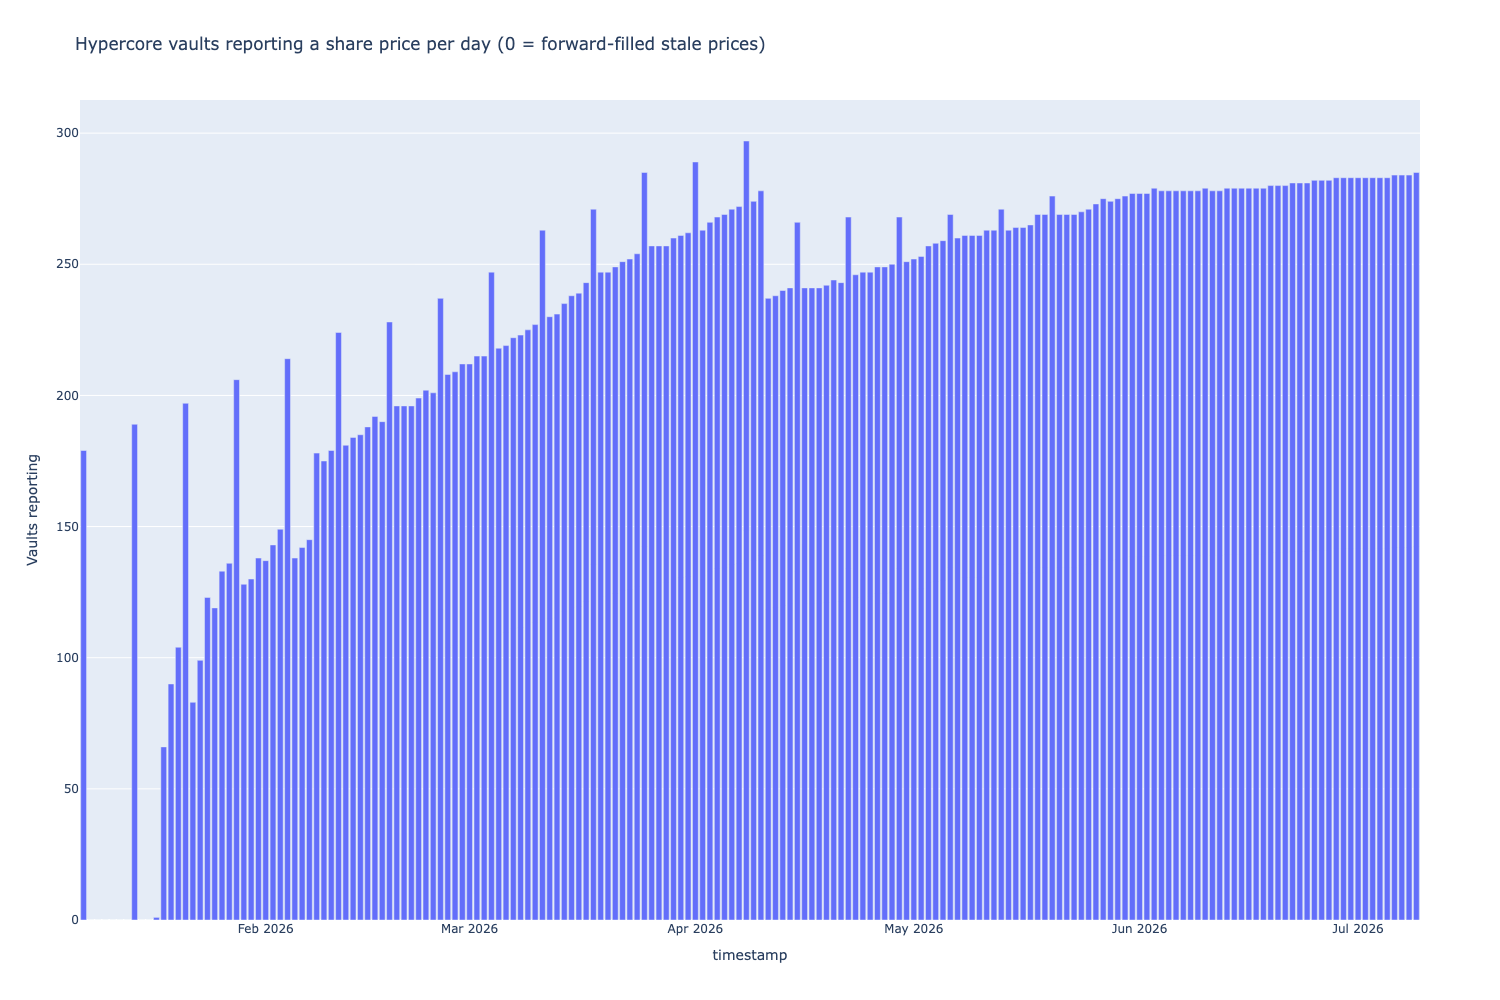

In [23]:
from pathlib import Path

VAULT_PRICE_PARQUET = Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-price-history.parquet"

# Measure the vaults this strategy actually trades, identified by address.
#
# Do NOT filter on `CHAIN_ID`: it is `ChainId.hyperliquid` (999, HyperEVM), while the tradeable
# vaults are Hypercore vaults on chain 9999. Filtering on 999 selects a different, fully covered
# set of vaults and reports 0% missing data.
traded_vault_addresses = {
    pair.pool_address.lower()
    for pair in strategy_universe.iterate_pairs()
    if pair.is_vault() and pair.pool_address
}
print(f"Measuring coverage for {len(traded_vault_addresses)} vault pairs in the strategy universe")

# `timestamp` is the parquet index, not a column.
coverage_raw = pd.read_parquet(VAULT_PRICE_PARQUET, columns=["chain", "address"]).reset_index()
coverage_raw = coverage_raw[coverage_raw["address"].str.lower().isin(traded_vault_addresses)]
coverage_raw = coverage_raw[
    (coverage_raw["timestamp"] >= Parameters.backtest_start)
    & (coverage_raw["timestamp"] < Parameters.backtest_end)
]
print(f"Chains represented: {sorted(coverage_raw['chain'].unique().tolist())}")

vaults_per_day = coverage_raw.set_index("timestamp").resample("1D")["address"].nunique()

coverage_by_month = vaults_per_day.groupby(pd.Grouper(freq="MS")).agg(
    days="size",
    days_with_data=lambda s: int((s > 0).sum()),
    mean_vaults_reporting="mean",
)
coverage_by_month["Coverage"] = coverage_by_month["days_with_data"] / coverage_by_month["days"]
display(coverage_by_month.style.format({
    "mean_vaults_reporting": "{:.0f}",
    "Coverage": "{:.0%}",
}).set_caption("Days on which any Hypercore vault reported a share price"))

data_days = vaults_per_day[vaults_per_day > 0].index

# The first date from which coverage stays daily for at least a fortnight.
DAILY_DATA_START = None
for offset in range(len(data_days) - 14):
    window_gaps = pd.Series(data_days[offset:offset + 14]).diff().dt.days.fillna(1)
    if (window_gaps == 1).all():
        DAILY_DATA_START = data_days[offset]
        break

assert DAILY_DATA_START is not None, "Never found a fortnight of continuous daily coverage"
assert DAILY_DATA_START > Parameters.backtest_start, (
    f"Daily coverage starts at the window start ({DAILY_DATA_START}), so the sub-window test below "
    f"would just repeat the full window - check that the address filter selected the traded vaults"
)

blank_days = int((vaults_per_day == 0).sum())
print(f"Days in window: {len(vaults_per_day)}   days with no price data at all: {blank_days} ({blank_days/len(vaults_per_day):.0%})")
print(f"Median gap between data days before {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days < DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Median gap between data days after  {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days >= DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Daily-resolution sub-window: {DAILY_DATA_START.date()} to {Parameters.backtest_end.date()}")

fig = px.bar(
    vaults_per_day,
    title="Hypercore vaults reporting a share price per day (0 = forward-filled stale prices)",
)
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Vaults reporting")
fig.show()


# Robustness diagnostics

In [24]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.curator import is_quarantined


def return_metrics(return_series: pd.Series) -> dict:
    return_series = return_series.dropna()
    cagr = float(calculate_cagr(return_series))
    max_drawdown = float(calculate_max_drawdown(return_series))
    return {
        'Cumulative return': float((1.0 + return_series).prod() - 1.0),
        'CAGR': cagr,
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': max_drawdown,
    }


daily_returns = calculate_returns(equity).resample('1D').sum(min_count=1).fillna(0.0)
profitable_returns = daily_returns[daily_returns > 0.0]
profitable_outlier_cutoff = profitable_returns.quantile(0.95)
profitable_outlier_mask = (daily_returns > 0.0) & (daily_returns > profitable_outlier_cutoff)
returns_without_best_days = daily_returns.mask(profitable_outlier_mask, 0.0)

robustness_df = pd.DataFrame([
    {'Scenario': 'Original', **return_metrics(daily_returns)},
    {
        'Scenario': 'Largest 5% profitable daily returns neutralised',
        **return_metrics(returns_without_best_days),
    },
]).set_index('Scenario')
display(robustness_df.style.format({
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
}))

best_day = pd.Timestamp(daily_returns.idxmax()).normalize()
daily_return_diagnostics_df = pd.DataFrame([{
    'Best day': best_day,
    'Best-day return': float(daily_returns.max()),
    'Worst day': pd.Timestamp(daily_returns.idxmin()).normalize(),
    'Worst-day return': float(daily_returns.min()),
    'Best-day share of positive daily returns': float(daily_returns.max() / profitable_returns.sum()),
    'Daily-return skew': float(daily_returns.skew()),
    'Daily excess kurtosis': float(daily_returns.kurtosis()),
    'Neutralised profitable days': int(profitable_outlier_mask.sum()),
    'Neutralisation cutoff': float(profitable_outlier_cutoff),
}])
display(daily_return_diagnostics_df.style.format({
    'Best-day return': '{:.2%}',
    'Worst-day return': '{:.2%}',
    'Best-day share of positive daily returns': '{:.1%}',
    'Daily-return skew': '{:.2f}',
    'Daily excess kurtosis': '{:.2f}',
    'Neutralisation cutoff': '{:.2%}',
}))

valuation_rows = []
for position in positions:
    for update in position.valuation_updates:
        valuation_day = pd.Timestamp(update.valued_at).normalize()
        if valuation_day != best_day or update.old_value is None:
            continue
        valuation_rows.append({
            'Vault': position.pair.base.token_symbol,
            'Vault address': position.pair.pool_address,
            'Valuation change USD': float(update.new_value - update.old_value),
            'Curator-quarantined on best day': is_quarantined(
                position.pair.pool_address,
                best_day.to_pydatetime(),
            ),
        })

best_day_valuation_df = pd.DataFrame(valuation_rows)
if len(best_day_valuation_df):
    best_day_valuation_df = best_day_valuation_df.sort_values('Valuation change USD', ascending=False)
display(best_day_valuation_df.head(12).style.format({'Valuation change USD': '${:,.0f}'}))



from tradeexecutor.curator.curator import QUARANTINE_PERIODS

quarantine_overlap_rows = []
for position in positions:
    position_address = position.pair.pool_address.lower()
    position_end = position.closed_at or Parameters.backtest_end
    for address, quarantine_start, quarantine_end, reason in QUARANTINE_PERIODS:
        if position_address != address.lower():
            continue
        if position.opened_at <= quarantine_end and position_end >= quarantine_start:
            quarantine_overlap_rows.append({
                'Vault': position.pair.base.token_symbol,
                'Opened': position.opened_at,
                'Closed': position.closed_at,
                'Quarantine start': quarantine_start,
                'Quarantine end': quarantine_end,
                'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
                'Reason': reason,
            })

quarantine_overlap_df = pd.DataFrame(quarantine_overlap_rows)
display(quarantine_overlap_df.style.format({'Realised profit USD': '${:,.0f}'}).set_caption('Curator quarantine overlap audit'))



best_day_position_rows = []
for position in positions:
    position_end = position.closed_at or Parameters.backtest_end
    if not (position.opened_at <= best_day.to_pydatetime() <= position_end):
        continue
    candles = strategy_universe.data_universe.candles.get_candles_by_pair(position.pair.internal_id)
    candle_closes = candles.set_index('timestamp')['close'].sort_index()
    # The equity curve is sampled once per strategy cycle, so on a 2-day cadence the "best day"
    # booked a two-day move. Measure each vault over the same span - comparing against yesterday's
    # close attributes only the final day and can show every holding flat while the portfolio jumps.
    equity_sample_days = pd.DatetimeIndex(equity.index).normalize()
    earlier_samples = equity_sample_days[equity_sample_days < best_day]
    span_start = earlier_samples[-1] if len(earlier_samples) else best_day - pd.Timedelta(days=1)
    close_on_best_day = candle_closes.loc[candle_closes.index <= best_day].iloc[-1]
    close_before_best_day = candle_closes.loc[candle_closes.index <= span_start].iloc[-1]
    best_day_position_rows.append({
        'Vault': position.pair.base.token_symbol,
        'Position opened': position.opened_at,
        'Position closed': position.closed_at,
        'Vault return over the best step': float(close_on_best_day / close_before_best_day - 1.0),
        'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
        'Curator-quarantined on best day': is_quarantined(
            position.pair.pool_address,
            best_day.to_pydatetime(),
        ),
    })

best_day_positions_df = pd.DataFrame(best_day_position_rows).sort_values(
    'Vault return over the best step',
    ascending=False,
)
display(
    best_day_positions_df.style.format({
        'Vault return over the best step': '{:.2%}',
        'Realised profit USD': '${:,.0f}',
    }).set_caption('Position moves on the best portfolio day')
)


,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown
Scenario,,,,,
Original,24.93%,54.06%,3.34,6.24,-3.63%
Largest 5% profitable daily returns neutralised,15.26%,31.76%,2.45,3.99,-3.63%


,Best day,Best-day return,Worst day,Worst-day return,Best-day share of positive daily returns,Daily-return skew,Daily excess kurtosis,Neutralised profitable days,Neutralisation cutoff
0,2026-06-26 00:00:00,3.16%,2026-04-11 00:00:00,-3.28%,7.8%,0.84,8.20,3,2.44%


,Vault,Position opened,Position closed,Vault return over the best step,Realised profit USD,Curator-quarantined on best day
7,Scared Mon,2026-06-20 00:00:00,None,10.79%,$113,False
6,Goon Edgin,2026-06-20 00:00:00,None,9.45%,$580,False
3,Realist Ca,2026-03-08 00:00:00,None,4.79%,"$10,250",False
5,Octavious,2026-06-04 00:00:00,None,3.76%,$669,False
8,Mad Scient,2026-06-22 00:00:00,None,1.07%,$-2,False
1,Gucky_1coi,2026-01-25 00:00:00,None,0.98%,"$1,079",False
2,Citadel,2026-01-29 00:00:00,None,0.00%,$154,False
4,DOEZOE,2026-05-31 00:00:00,None,0.00%,$-22,False
0,pmalt,2026-01-05 00:00:00,None,-0.73%,"$8,138",False


# Forensics: where does the money go?

The accounting identity used throughout this chain is

    final equity == initial cash + realised P&L + unrealised P&L - redemption fees

When it fails, one of four things is true, and they are distinguishable:

1. **The identity itself is wrong** - the fee estimate, or the treatment of closed positions, does
   not match how the engine books things. This would be *my* bug, not the engine's, and it would
   show up as a gap that is present even in runs everyone considers healthy.
2. **Reported P&L disagrees with the trades.** A position's realised plus unrealised profit does not
   equal what its own buys and sells imply. This localises to specific positions.
3. **Equity disagrees with holdings.** Total equity does not equal cash plus the market value of
   open positions. This is an engine-level valuation problem.
4. **Value is destroyed on close** - the NB74 dust signature, positions funded with cash that close
   returning nothing.

Each is tested separately below, on the **worst** incoherent configuration from NB80's second pass.


In [25]:
#: The NB80 configuration with the largest accounting gap: -6.24% of capital.
#: 360d CAGR lookback, 0.70 CAGR weight, -0.16 gate, 75d volatility window, 8 vaults,
#: 120d Sortino window, inverse_variance sizing, Sortino selection score.
EXPECTED_GAP = -0.0624

pf = state.portfolio

realised_total = sum(float(p.get_realised_profit_usd() or 0) for p in pf.get_all_positions())
unrealised_total = sum(float(p.get_unrealised_profit_usd() or 0)
                       for p in pf.open_positions.values() if not p.is_credit_supply())
sells = [t for t in pf.get_all_trades() if t.pair.is_vault() and t.is_sell() and t.is_success()]
sell_volume = sum(abs(float(t.executed_reserve or 0)) for t in sells)
fee_estimate = sell_volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee)

reported_equity = float(pf.get_total_equity())
identity_equity = Parameters.initial_cash + realised_total + unrealised_total - fee_estimate
gap = (reported_equity - identity_equity) / Parameters.initial_cash

print(f"Reproduced gap: {gap:+.2%} of capital (NB80 reported {EXPECTED_GAP:+.2%})")
print(f"Reproduces: {abs(gap - EXPECTED_GAP) < 0.01}")
print()

# Test 3 first: does equity equal cash plus holdings? If not, nothing downstream is meaningful.
cash = float(pf.get_cash())
open_value = sum(float(p.get_value() or 0) for p in pf.open_positions.values())
print(f"Cash                       ${cash:,.2f}")
print(f"Open position market value ${open_value:,.2f}")
print(f"Sum                        ${cash + open_value:,.2f}")
print(f"Reported total equity      ${reported_equity:,.2f}")
print(f"Difference                 ${cash + open_value - reported_equity:,.2f}")


Reproduced gap: -6.24% of capital (NB80 reported -6.24%)
Reproduces: True

Cash                       $2,836.49
Open position market value $184,380.06
Sum                        $187,216.55
Reported total equity      $187,216.55
Difference                 $0.00


## Test 2 - does each position's reported P&L match its own trades?

For every position, what its buys and sells imply is compared with what it reports. A position that
bought \$X, sold \$Y and still holds \$Z should report ``Y + Z - X`` in total profit. Any position
where that fails is where the money went.


In [26]:
rows = []
for position in pf.get_all_positions():
    if position.is_credit_supply():
        continue
    buys = sum(abs(float(t.executed_reserve or 0))
               for t in position.trades.values() if t.is_buy() and t.is_success())
    sold = sum(abs(float(t.executed_reserve or 0))
               for t in position.trades.values() if t.is_sell() and t.is_success())
    still_held = float(position.get_value() or 0.0) if position.is_open() else 0.0
    implied = sold + still_held - buys
    realised = float(position.get_realised_profit_usd() or 0)
    unrealised = float(position.get_unrealised_profit_usd() or 0) if position.is_open() else 0.0
    reported = realised + unrealised
    rows.append({
        "Vault": position.pair.base.token_symbol,
        "Opened": position.opened_at,
        "Open": position.is_open(),
        "Buys USD": buys,
        "Sells USD": sold,
        "Still held USD": still_held,
        "Implied P&L": implied,
        "Reported P&L": reported,
        "Discrepancy": implied - reported,
        "Trades": len(position.trades),
    })

ledger = pd.DataFrame(rows)
ledger["Abs discrepancy"] = ledger["Discrepancy"].abs()
total_disc = float(ledger["Discrepancy"].sum())
print(f"Positions: {len(ledger)}   total discrepancy ${total_disc:,.2f} "
      f"({total_disc / Parameters.initial_cash:+.2%} of capital)")
print(f"Positions with |discrepancy| > $100: {(ledger['Abs discrepancy'] > 100).sum()}")
print()
print("The redemption fee explains part of this by construction - a sell books its proceeds net of")
print("fee, so 'implied' is short by the fee on every sell. Expected fee drag:"
      f" ${fee_estimate:,.2f}")
print(f"Discrepancy net of the fee estimate: ${total_disc + fee_estimate:,.2f}")

display(
    ledger.sort_values("Abs discrepancy", ascending=False).head(12)
    .drop(columns=["Abs discrepancy"])
    .style.format({
        "Buys USD": "${:,.0f}", "Sells USD": "${:,.0f}", "Still held USD": "${:,.0f}",
        "Implied P&L": "${:,.0f}", "Reported P&L": "${:,.0f}", "Discrepancy": "${:,.0f}",
    }, na_rep="-")
    .set_caption("Twelve positions whose reported P&L differs most from what their trades imply")
)


Positions: 73   total discrepancy $-11,693.93 (-7.80% of capital)
Positions with |discrepancy| > $100: 5

The redemption fee explains part of this by construction - a sell books its proceeds net of
fee, so 'implied' is short by the fee on every sell. Expected fee drag: $2,340.53
Discrepancy net of the fee estimate: $-9,353.40


,Vault,Opened,Open,Buys USD,Sells USD,Still held USD,Implied P&L,Reported P&L,Discrepancy,Trades
0,pmalt,2026-01-05 00:00:00,True,"$146,114","$132,766","$19,533","$6,185","$13,028","$-6,844",59
3,Realist Ca,2026-03-08 00:00:00,True,"$124,115","$119,583","$26,479","$21,947","$24,809","$-2,861",49
2,Citadel,2026-01-29 00:00:00,True,"$113,381","$53,879","$60,546","$1,043","$2,070","$-1,027",55
5,Octavious,2026-06-04 00:00:00,True,"$13,878","$7,604","$6,868",$594,"$1,069",$-475,6
6,Goon Edgin,2026-06-20 00:00:00,True,"$44,229","$9,568","$36,938","$2,277","$2,683",$-406,9
1,Gucky_1coi,2026-01-25 00:00:00,True,"$49,981","$50,522",$565,"$1,106","$1,162",$-56,25
7,Scared Mon,2026-06-20 00:00:00,True,"$13,956","$6,656","$8,900","$1,600","$1,649",$-49,8
4,DOEZOE,2026-05-31 00:00:00,True,"$11,420","$5,768","$5,189",$-463,$-486,$23,9
8,Mad Scient,2026-06-22 00:00:00,True,"$19,536",$802,"$19,362",$628,$627,$1,6
62,Hyperliqui,2026-05-23 00:00:00,False,"$54,408","$54,363",$0,$-45,$-45,$0,3


## Test 4 - was value destroyed on close?

The NB74 signature: a position funded with real cash that closes returning nothing. This is what
trade-executor [#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621) fixed for
Hypercore dust, so finding any here would mean either a regression or a second path to the same
outcome.


In [27]:
destroyed = []
for position in pf.get_all_positions():
    if position.is_credit_supply() or position.is_open():
        continue
    buys = sum(abs(float(t.executed_reserve or 0))
               for t in position.trades.values() if t.is_buy() and t.is_success())
    sold = sum(abs(float(t.executed_reserve or 0))
               for t in position.trades.values() if t.is_sell() and t.is_success())
    if buys > 100 and sold < 1.0:
        destroyed.append({"Vault": position.pair.base.token_symbol, "Opened": position.opened_at,
                          "Closed": position.closed_at, "Funded USD": buys, "Returned USD": sold,
                          "Quantity left": float(position.get_quantity() or 0)})
if destroyed:
    display(pd.DataFrame(destroyed).style.format({"Funded USD": "${:,.0f}", "Returned USD": "${:,.0f}"})
            .set_caption("Positions funded but closed returning nothing"))
    print(f"{len(destroyed)} destroyed position(s), ${sum(d['Funded USD'] for d in destroyed):,.0f} funded")
else:
    print("No destroyed positions - the NB74 dust signature is absent.")

# Residual quantity on closed positions: value left stranded in a position the books call closed.
stranded = []
for position in pf.get_all_positions():
    if position.is_open() or position.is_credit_supply():
        continue
    quantity = float(position.get_quantity() or 0)
    if abs(quantity) > 1e-9:
        price = float(position.last_token_price or 0)
        stranded.append({"Vault": position.pair.base.token_symbol, "Closed": position.closed_at,
                         "Quantity left": quantity, "Last price": price,
                         "Value stranded USD": quantity * price})
if stranded:
    df_str = pd.DataFrame(stranded)
    print(f"\n{len(df_str)} closed position(s) still hold quantity, "
          f"${df_str['Value stranded USD'].sum():,.2f} total")
    display(df_str.sort_values("Value stranded USD", key=abs, ascending=False).head(10)
            .style.format({"Value stranded USD": "${:,.2f}", "Last price": "{:,.4f}"})
            .set_caption("Closed positions still holding quantity"))
else:
    print("\nNo closed position holds residual quantity.")


No destroyed positions - the NB74 dust signature is absent.

No closed position holds residual quantity.


## Test 1 - is the identity itself wrong?

The decisive control. The same forensic decomposition is applied to **NB75's configuration**, which
reconciles to +0.55% and is the accepted candidate. If the per-position discrepancies look the same
shape there, the identity is mis-specified and the "failures" are partly my measurement rather than
the engine's books.


In [28]:
from tradeexecutor.backtest.backtest_execution import BacktestExecutionFailed


def forensic_summary(run_state, label: str, capital: float) -> dict:
    """Identity gap plus its per-position decomposition for one run."""
    p = run_state.portfolio
    realised = sum(float(x.get_realised_profit_usd() or 0) for x in p.get_all_positions())
    unrealised = sum(float(x.get_unrealised_profit_usd() or 0)
                     for x in p.open_positions.values() if not x.is_credit_supply())
    s_ = [t for t in p.get_all_trades() if t.pair.is_vault() and t.is_sell() and t.is_success()]
    volume = sum(abs(float(t.executed_reserve or 0)) for t in s_)
    fee = volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee)
    reported = float(p.get_total_equity())
    gap_ = (reported - (capital + realised + unrealised - fee)) / capital

    disc = 0.0
    worst = 0.0
    for position in p.get_all_positions():
        if position.is_credit_supply():
            continue
        buys = sum(abs(float(t.executed_reserve or 0))
                   for t in position.trades.values() if t.is_buy() and t.is_success())
        sold = sum(abs(float(t.executed_reserve or 0))
                   for t in position.trades.values() if t.is_sell() and t.is_success())
        held = float(position.get_value() or 0.0) if position.is_open() else 0.0
        rep = (float(position.get_realised_profit_usd() or 0)
               + (float(position.get_unrealised_profit_usd() or 0) if position.is_open() else 0.0))
        d = (sold + held - buys) - rep
        disc += d
        worst = d if abs(d) > abs(worst) else worst

    return {
        "Run": label, "Identity gap %": gap_, "Coherent": abs(gap_) <= 0.01,
        "Cash + holdings - equity": float(p.get_cash()) + sum(
            float(x.get_value() or 0) for x in p.open_positions.values()) - reported,
        "Sum position discrepancy": disc,
        "Discrepancy net of fee": disc + fee,
        "Worst single position": worst,
        "Positions": len([x for x in p.get_all_positions() if not x.is_credit_supply()]),
    }


control_parameters = StrategyParameters.from_dict(dict(parameters))
control_parameters["selection_score_indicator"] = "cagr_sharpe_weight"
control_parameters["max_assets_in_portfolio"] = 6
control_parameters["per_position_cap_of_pool_pct"] = 0.25
control_parameters["inverse_vol_window"] = 45
control_parameters["sharpe_lookback_days"] = 180
control_parameters["cagr_weight"] = 0.50
control_parameters["gate_threshold"] = -0.08

control_result = run_backtest_inline(
    name="NB75 candidate (coherent control)",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=control_parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

comparison = pd.DataFrame([
    forensic_summary(state, "This notebook (NB80 worst incoherent)", Parameters.initial_cash),
    forensic_summary(control_result.state, "NB75 candidate (coherent control)", Parameters.initial_cash),
]).set_index("Run")
display(
    comparison.style.format({
        "Identity gap %": "{:+.2%}", "Cash + holdings - equity": "${:,.2f}",
        "Sum position discrepancy": "${:,.2f}", "Discrepancy net of fee": "${:,.2f}",
        "Worst single position": "${:,.2f}",
    }).set_caption("Forensic decomposition: failing configuration versus a known-good one")
)


,Identity gap %,Coherent,Cash + holdings - equity,Sum position discrepancy,Discrepancy net of fee,Worst single position,Positions
Run,,,,,,,
This notebook (NB80 worst incoherent),-6.24%,False,$0.00,"$-11,693.93","$-9,353.40","$-6,843.89",73
NB75 candidate (coherent control),+0.78%,True,$0.00,"$-1,074.68","$1,174.17",$-892.23,77
